In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# *TASK 1: Big Data Ecosystem Architecture Setup*

# Step 1.1: Environment Setup

In [3]:
import subprocess
print("Checking GPU availability...")
try:
    gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'])
    print("GPU DETECTED:")
    print(gpu_info.decode('utf-8'))
except:
    print("No GPU detected - running on CPU")

!pkill -9 java 2>/dev/null || true
import time
time.sleep(2)
print("\nInstalling Java 11...")
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless > /dev/null

print("Installing PySpark and libraries...")
!pip install -q pyspark==3.5.1 findspark pyvis networkx statsmodels
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-11-openjdk-amd64/bin"
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
print("\nVerifying Java installation:")
!java -version

import findspark
findspark.init()
print("\n Spark is ready!")
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import networkx as nx
from pyvis.network import Network
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print(" All libraries imported successfully")


Checking GPU availability...
GPU DETECTED:
Tesla T4, 15360 MiB, 15095 MiB


Installing Java 11...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installing PySpark and libraries...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.1 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.

Verifying Java installation

# Step 1.2: Initialize Spark Cluster

In [4]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("SupplyChainAnalytics_Distributed") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("SPARK CLUSTER CONFIGURATION")
print(f"Spark Version:         {spark.version}")
print(f"Master:                {spark.sparkContext.master}")
print(f"App Name:              {spark.sparkContext.appName}")
print(f"Available Cores:       {spark.sparkContext.defaultParallelism}")
print(f"Driver Memory:         6GB")
print(f"Executor Memory:       6GB")
print(f"Shuffle Partitions:    8")
print(" Spark session created successfully!")


SPARK CLUSTER CONFIGURATION
Spark Version:         3.5.1
Master:                local[*]
App Name:              SupplyChainAnalytics_Distributed
Available Cores:       2
Driver Memory:         6GB
Executor Memory:       6GB
Shuffle Partitions:    8
 Spark session created successfully!


In [5]:
spark = SparkSession.builder \
    .appName("SupplyChainAnalytics") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Available cores: {spark.sparkContext.defaultParallelism}")
print(f"Driver memory: 6GB")


Spark version: 3.5.1
Available cores: 2
Driver memory: 6GB


# Step 1.3: Load Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Open_ended_experiment_Big_Data_lab/supply_chain_dataset.csv"

df = spark.read.csv(dataset_path, header=True, inferSchema=True, ignoreLeadingWhiteSpace=True)
df_pd = pd.read_csv(dataset_path)

print(f"Loaded {df.count():,} records with {len(df.columns)} columns")
print(f"Current partitions: {df.rdd.getNumPartitions()}")

# IMPORTANT: Create all derived features immediately
df_pd['Date'] = pd.to_datetime(df_pd['Date'])
df_pd['Profit_Margin'] = df_pd['Unit_Price'] - df_pd['Unit_Cost']
df_pd['Forecast_Error'] = np.abs(df_pd['Demand_Forecast'] - df_pd['Units_Sold'])
df_pd['Revenue'] = df_pd['Units_Sold'] * df_pd['Unit_Price']
df_pd['Total_Cost'] = df_pd['Units_Sold'] * df_pd['Unit_Cost']
df_pd['Net_Profit'] = df_pd['Revenue'] - df_pd['Total_Cost']
df_pd['Days_Inventory'] = df_pd['Inventory_Level'] / (df_pd['Units_Sold'] + 1)
df_pd['Turnover_Ratio'] = df_pd['Units_Sold'] / (df_pd['Inventory_Level'] + 1)
df_pd['Profit_Pct'] = (df_pd['Profit_Margin'] / df_pd['Unit_Cost']) * 100

print("\nDerived features created successfully")
print(f"Total columns: {len(df_pd.columns)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 91,250 records with 15 columns
Current partitions: 2

Derived features created successfully
Total columns: 23


# Step 1.4: Architecture Visualization

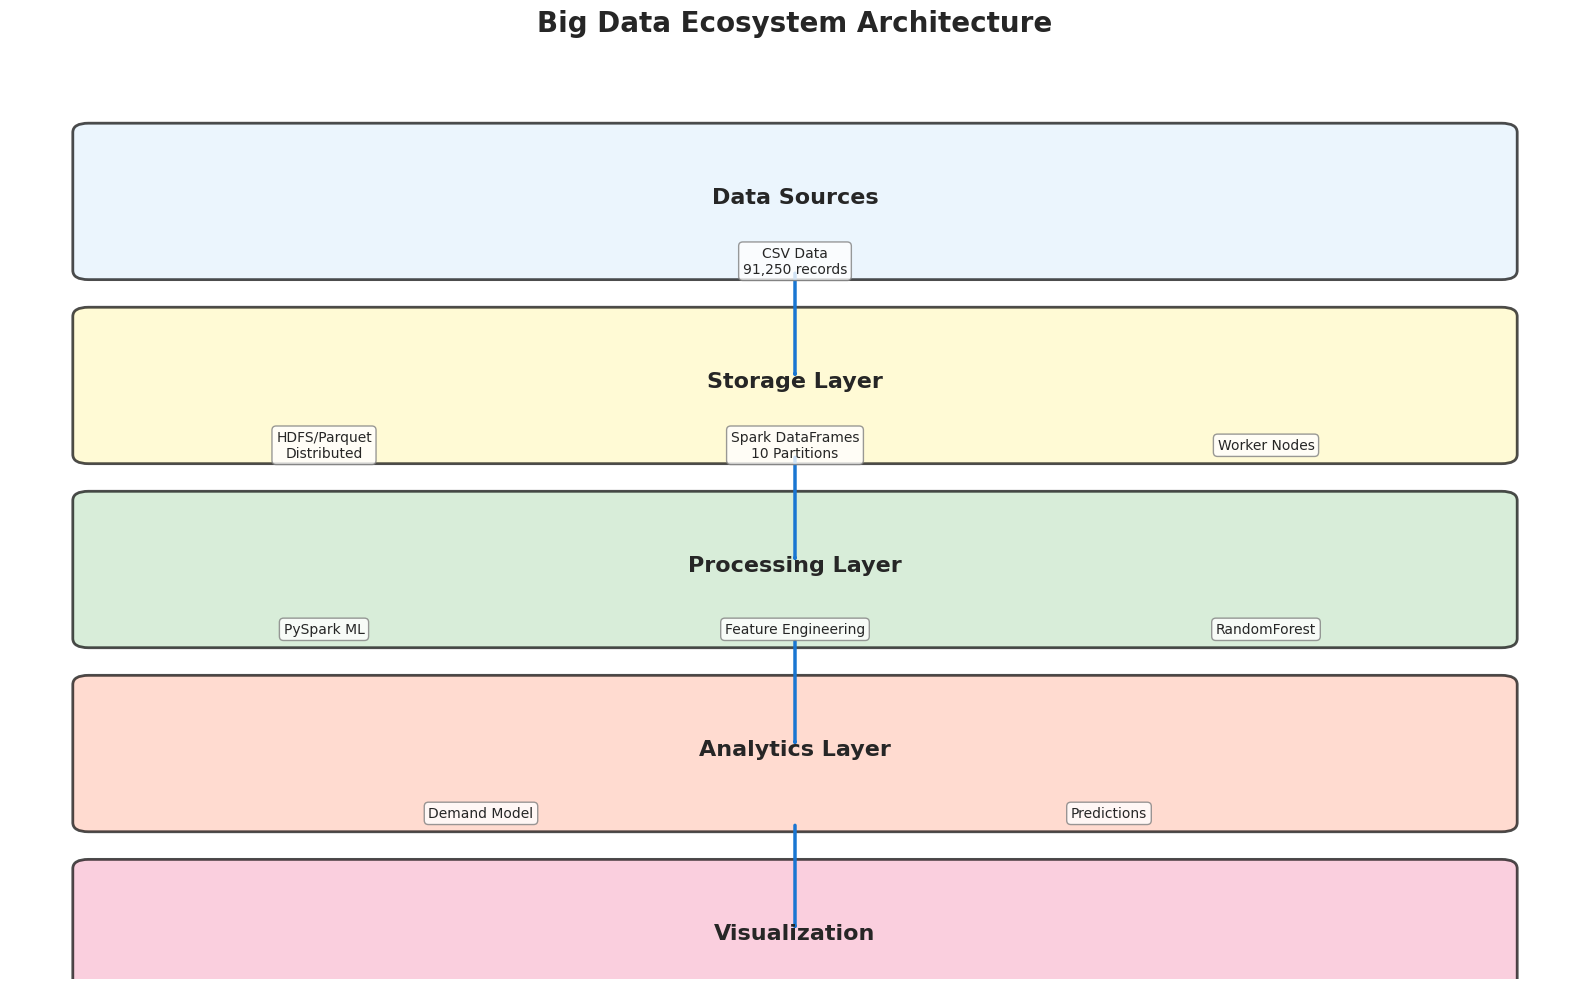

In [7]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

layers_info = {
    'Data Sources': (0.85, '#E3F2FD'),
    'Storage Layer': (0.65, '#FFF9C4'),
    'Processing Layer': (0.45, '#C8E6C9'),
    'Analytics Layer': (0.25, '#FFCCBC'),
    'Visualization': (0.05, '#F8BBD0')
}

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

for layer_name, (ypos, color) in layers_info.items():
    box = FancyBboxPatch((0.05, ypos - 0.08), 0.9, 0.15,
                          boxstyle="round,pad=0.01",
                          edgecolor='black',
                          facecolor=color,
                          linewidth=2,
                          alpha=0.7)
    ax.add_patch(box)
    ax.text(0.5, ypos, layer_name, ha='center', va='center',
            fontsize=16, fontweight='bold')

components = [
    (0.5, 0.78, "CSV Data\n91,250 records"),
    (0.2, 0.58, "HDFS/Parquet\nDistributed"),
    (0.5, 0.58, "Spark DataFrames\n10 Partitions"),
    (0.8, 0.58, "Worker Nodes"),
    (0.2, 0.38, "PySpark ML"),
    (0.5, 0.38, "Feature Engineering"),
    (0.8, 0.38, "RandomForest"),
    (0.3, 0.18, "Demand Model"),
    (0.7, 0.18, "Predictions"),
]

for x, y, text in components:
    ax.text(x, y, text, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor='gray', alpha=0.8))

arrows = [(0.77, 0.65), (0.57, 0.45), (0.37, 0.25), (0.17, 0.05)]
for y1, y2 in arrows:
    arr = FancyArrowPatch((0.5, y1), (0.5, y2),
                         arrowstyle='->', lw=2.5, color='#1976D2')
    ax.add_patch(arr)

plt.title("Big Data Ecosystem Architecture", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# **TASK 2: Real-World Scenario Analysis**

# Step 2.1: Dataset Schema and Statistics

In [8]:
df.printSchema()
df.describe().show()

null_counts = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
                         for c in df.columns])
print("Missing values check:")
null_counts.show()


root
 |-- Date: date (nullable = true)
 |-- SKU_ID: string (nullable = true)
 |-- Warehouse_ID: string (nullable = true)
 |-- Supplier_ID: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Units_Sold: integer (nullable = true)
 |-- Inventory_Level: integer (nullable = true)
 |-- Supplier_Lead_Time_Days: integer (nullable = true)
 |-- Reorder_Point: integer (nullable = true)
 |-- Order_Quantity: integer (nullable = true)
 |-- Unit_Cost: double (nullable = true)
 |-- Unit_Price: double (nullable = true)
 |-- Promotion_Flag: integer (nullable = true)
 |-- Stockout_Flag: integer (nullable = true)
 |-- Demand_Forecast: double (nullable = true)

+-------+------+------------+-----------+------+------------------+------------------+-----------------------+-----------------+-----------------+------------------+------------------+-------------------+-------------+------------------+
|summary|SKU_ID|Warehouse_ID|Supplier_ID|Region|        Units_Sold|   Inventory_Level|Supplier_L

# Step 2.2: Problem Statement

In [9]:
print("Supply Chain Optimization Problem:")
print("- Predict demand to minimize forecast errors")
print("- Classify stockout risks across warehouses")
print("- Optimize inventory levels and reorder policies")
print("- Identify supplier performance bottlenecks\n")

print(f"Dataset size: {df_pd.shape[0]:,} transactions")
print(f"Features: {df_pd.shape[1]}")
print(f"Time period: 365 days")
print(f"Total SKUs: {df_pd['SKU_ID'].nunique()}")
print(f"Warehouses: {df_pd['Warehouse_ID'].nunique()}")
print(f"Suppliers: {df_pd['Supplier_ID'].nunique()}")


Supply Chain Optimization Problem:
- Predict demand to minimize forecast errors
- Classify stockout risks across warehouses
- Optimize inventory levels and reorder policies
- Identify supplier performance bottlenecks

Dataset size: 91,250 transactions
Features: 23
Time period: 365 days
Total SKUs: 50
Warehouses: 5
Suppliers: 10


# Step 2.3: Volume, Velocity, Variety Analysis

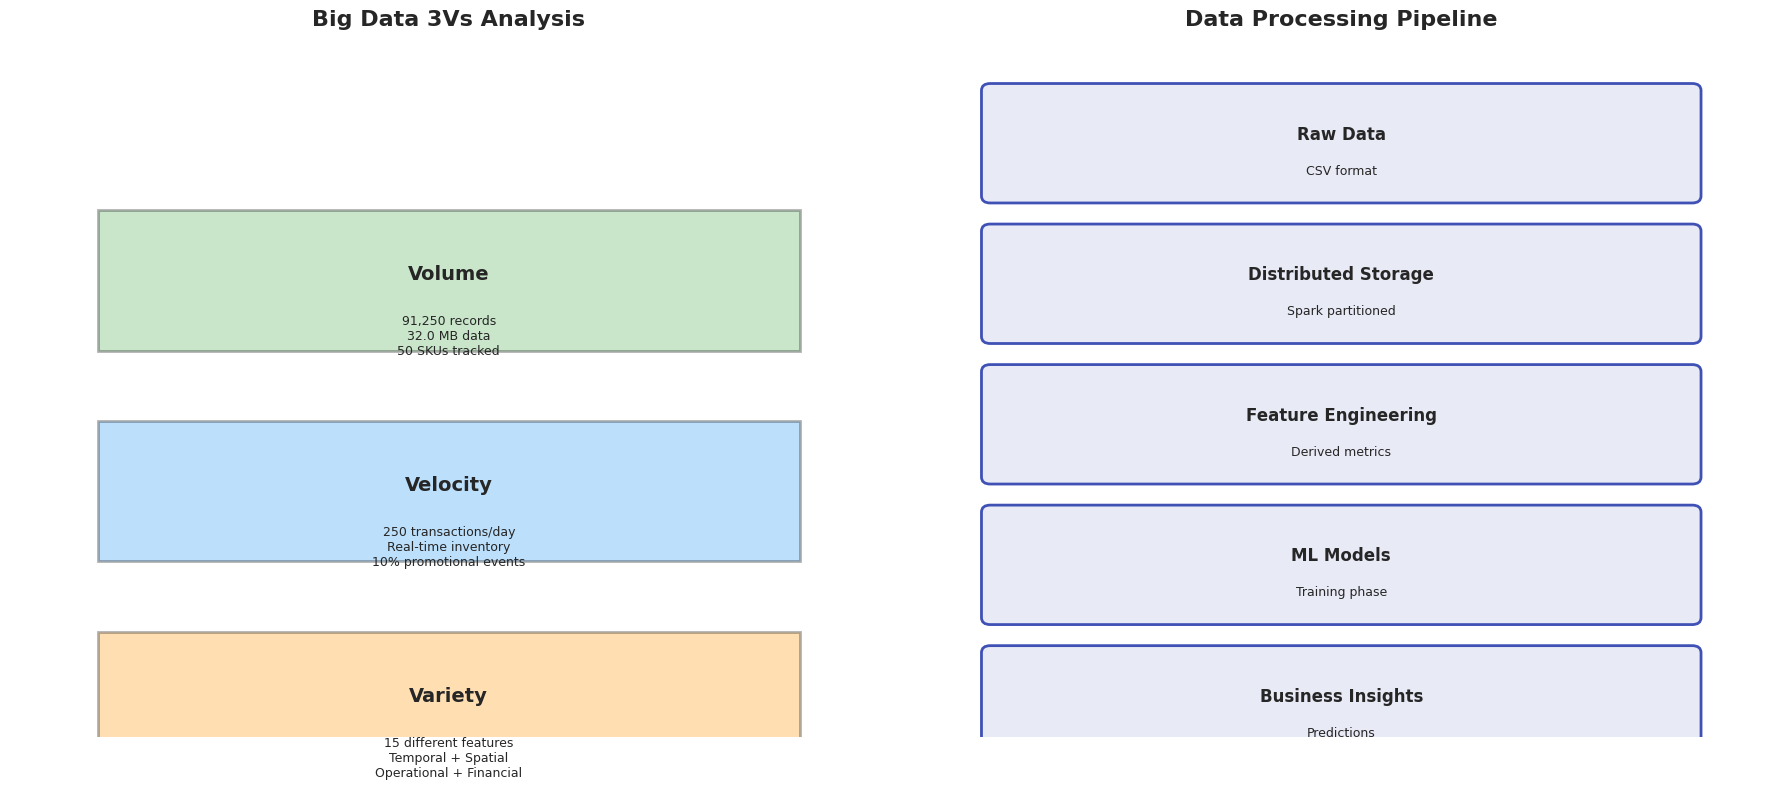

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.axis('off')
ax1.set_title("Big Data 3Vs Analysis", fontsize=16, fontweight='bold')

import matplotlib.patches as mpatches

v_characteristics = {
    'Volume': f"{df_pd.shape[0]:,} records\n{df_pd.memory_usage(deep=True).sum()/1024**2:.1f} MB data\n50 SKUs tracked",
    'Velocity': f"250 transactions/day\nReal-time inventory\n10% promotional events",
    'Variety': f"15 different features\nTemporal + Spatial\nOperational + Financial"
}

v_colors = ['#4CAF50', '#2196F3', '#FF9800']
yposition = 0.8

for (name, desc), col in zip(v_characteristics.items(), v_colors):
    rect = mpatches.Rectangle((0.1, yposition - 0.25), 0.8, 0.2,
                              facecolor=col, alpha=0.3,
                              edgecolor='black', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(0.5, yposition - 0.15, name, ha='center',
             fontsize=14, fontweight='bold')
    ax1.text(0.5, yposition - 0.20, desc, ha='center',
             fontsize=9, va='top')
    yposition -= 0.3

ax2.axis('off')
ax2.set_title("Data Processing Pipeline", fontsize=16, fontweight='bold')

pipeline_stages = [
    ("Raw Data", "CSV format", 0.85),
    ("Distributed Storage", "Spark partitioned", 0.65),
    ("Feature Engineering", "Derived metrics", 0.45),
    ("ML Models", "Training phase", 0.25),
    ("Business Insights", "Predictions", 0.05)
]

for stage_name, stage_desc, yval in pipeline_stages:
    stage_box = mpatches.FancyBboxPatch((0.1, yval - 0.08), 0.8, 0.15,
                                        boxstyle="round,pad=0.01",
                                        facecolor='#E8EAF6',
                                        edgecolor='#3F51B5',
                                        linewidth=2)
    ax2.add_patch(stage_box)
    ax2.text(0.5, yval, stage_name, ha='center',
             fontsize=12, fontweight='bold')
    ax2.text(0.5, yval - 0.05, stage_desc, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# Step 2.4: Exploratory Data Analysis - Part 1

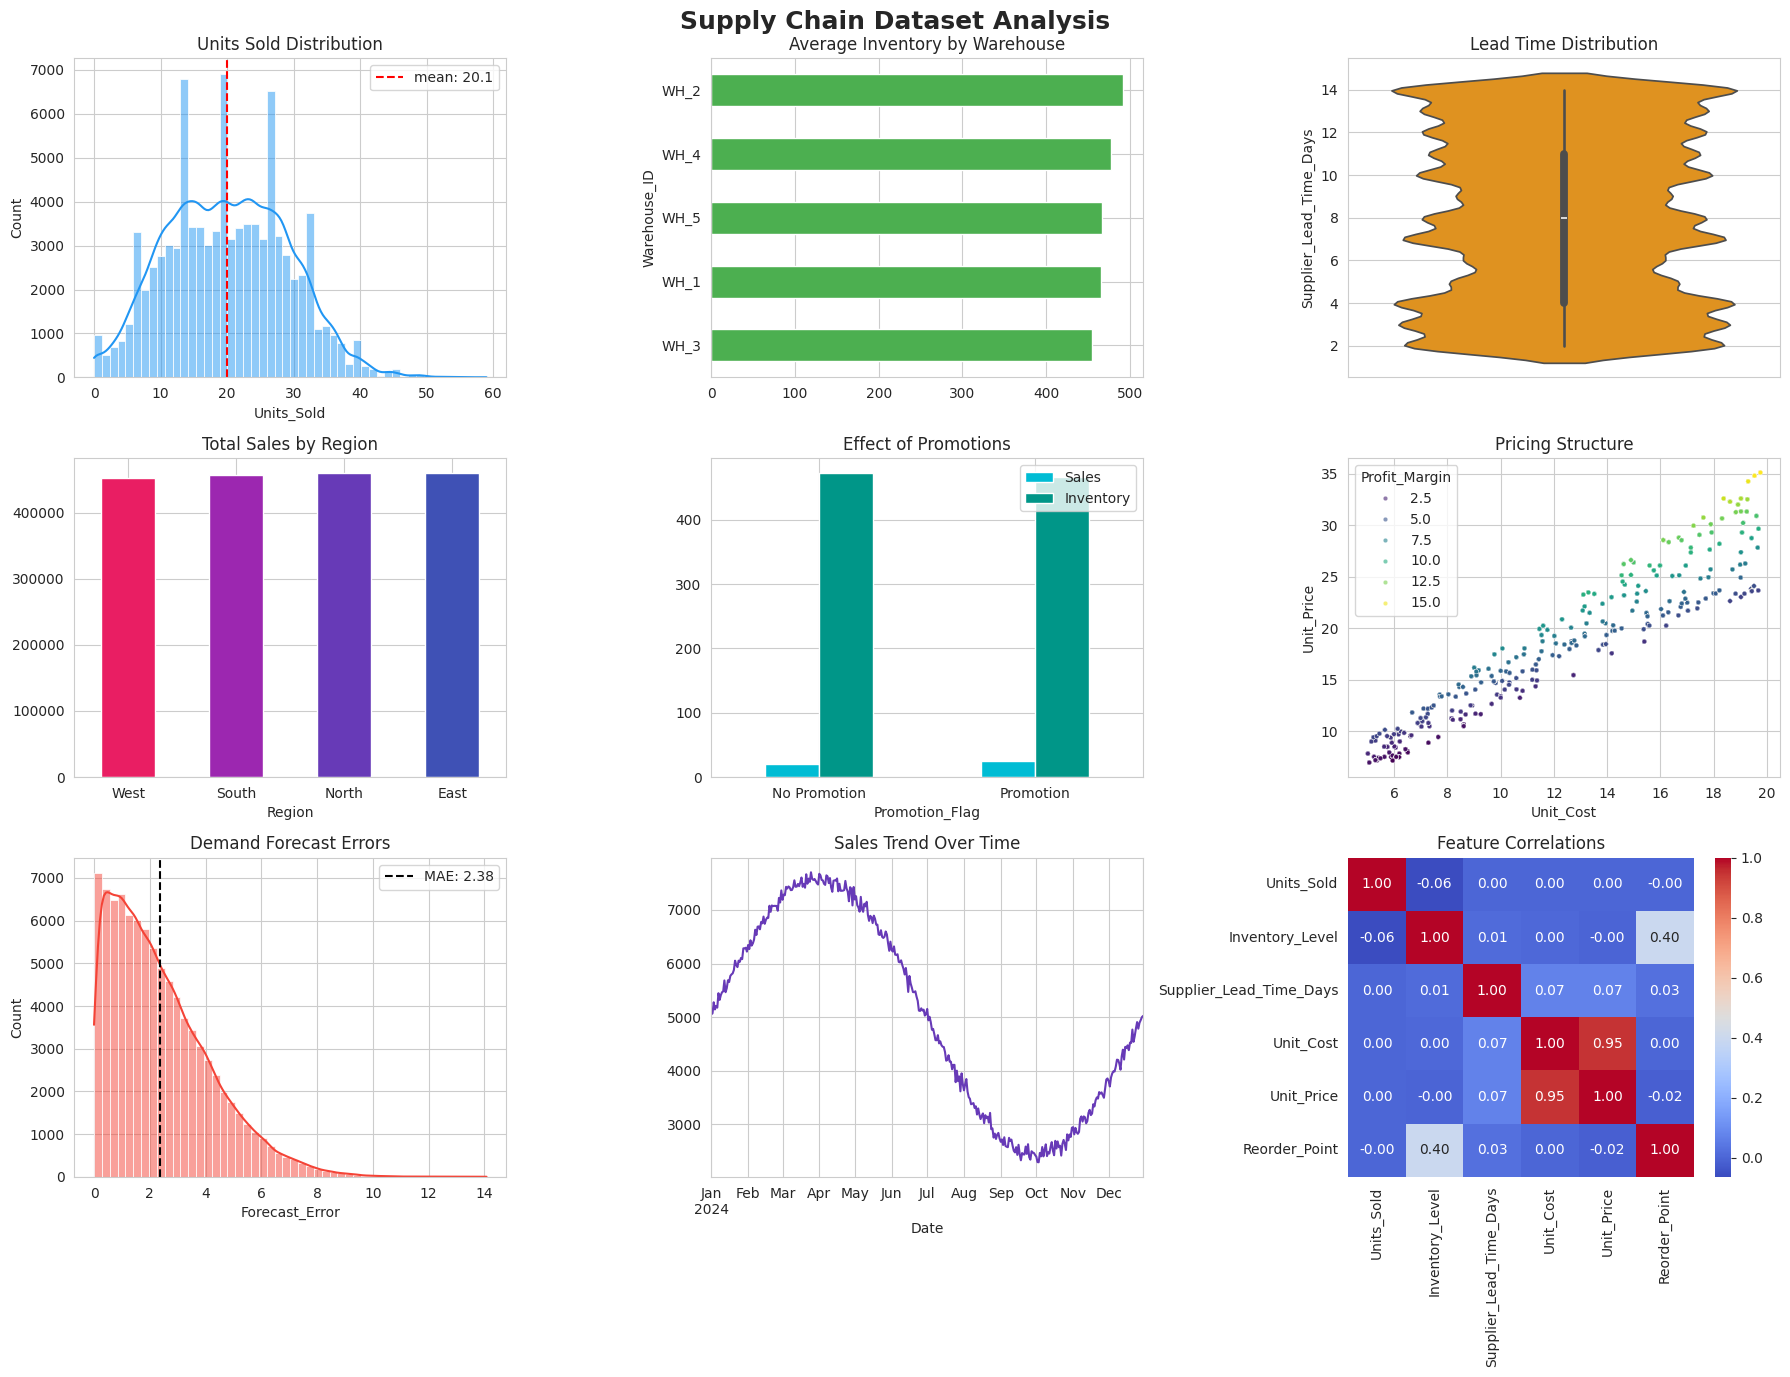

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Supply Chain Dataset Analysis', fontsize=18, fontweight='bold')

# Units sold distribution
sns.histplot(df_pd['Units_Sold'], bins=50, kde=True,
             color='#2196F3', ax=axes[0,0])
axes[0,0].set_title('Units Sold Distribution')
mean_sales = df_pd['Units_Sold'].mean()
axes[0,0].axvline(mean_sales, color='red', linestyle='--',
                  label=f"mean: {mean_sales:.1f}")
axes[0,0].legend()

# Warehouse inventory levels
warehouse_inv = df_pd.groupby('Warehouse_ID')['Inventory_Level'].mean().sort_values()
warehouse_inv.plot(kind='barh', ax=axes[0,1], color='#4CAF50')
axes[0,1].set_title('Average Inventory by Warehouse')

# Supplier lead time variability
sns.violinplot(data=df_pd, y='Supplier_Lead_Time_Days',
              ax=axes[0,2], color='#FF9800')
axes[0,2].set_title('Lead Time Distribution')

# Regional sales comparison
regional_sales = df_pd.groupby('Region')['Units_Sold'].sum().sort_values()
regional_sales.plot(kind='bar', ax=axes[1,0],
                   color=['#E91E63', '#9C27B0', '#673AB7', '#3F51B5'])
axes[1,0].set_title('Total Sales by Region')
axes[1,0].set_xticklabels(regional_sales.index, rotation=0)

# Promotion impact analysis
promo_analysis = df_pd.groupby('Promotion_Flag')[['Units_Sold', 'Inventory_Level']].mean()
promo_analysis.plot(kind='bar', ax=axes[1,1], color=['#00BCD4', '#009688'])
axes[1,1].set_title('Effect of Promotions')
axes[1,1].set_xticklabels(['No Promotion', 'Promotion'], rotation=0)
axes[1,1].legend(['Sales', 'Inventory'])

# Price vs cost analysis
sns.scatterplot(data=df_pd, x='Unit_Cost', y='Unit_Price',
               hue='Profit_Margin', palette='viridis',
               ax=axes[1,2], s=10, alpha=0.6)
axes[1,2].set_title('Pricing Structure')

# Forecast error analysis
sns.histplot(df_pd['Forecast_Error'], bins=50, kde=True,
            color='#F44336', ax=axes[2,0])
axes[2,0].set_title('Demand Forecast Errors')
mae_current = df_pd['Forecast_Error'].mean()
axes[2,0].axvline(mae_current, color='black', linestyle='--',
                 label=f"MAE: {mae_current:.2f}")
axes[2,0].legend()

# Time series trend
daily_sales = df_pd.groupby('Date')['Units_Sold'].sum()
daily_sales.plot(ax=axes[2,1], color='#673AB7', linewidth=1.5)
axes[2,1].set_title('Sales Trend Over Time')
axes[2,1].set_xlabel('Date')

# Correlation matrix
numerical_cols = ['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days',
                 'Unit_Cost', 'Unit_Price', 'Reorder_Point']
correlation_matrix = df_pd[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
           cmap='coolwarm', ax=axes[2,2])
axes[2,2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()


# Step 2.5: Outlier Detection Analysis

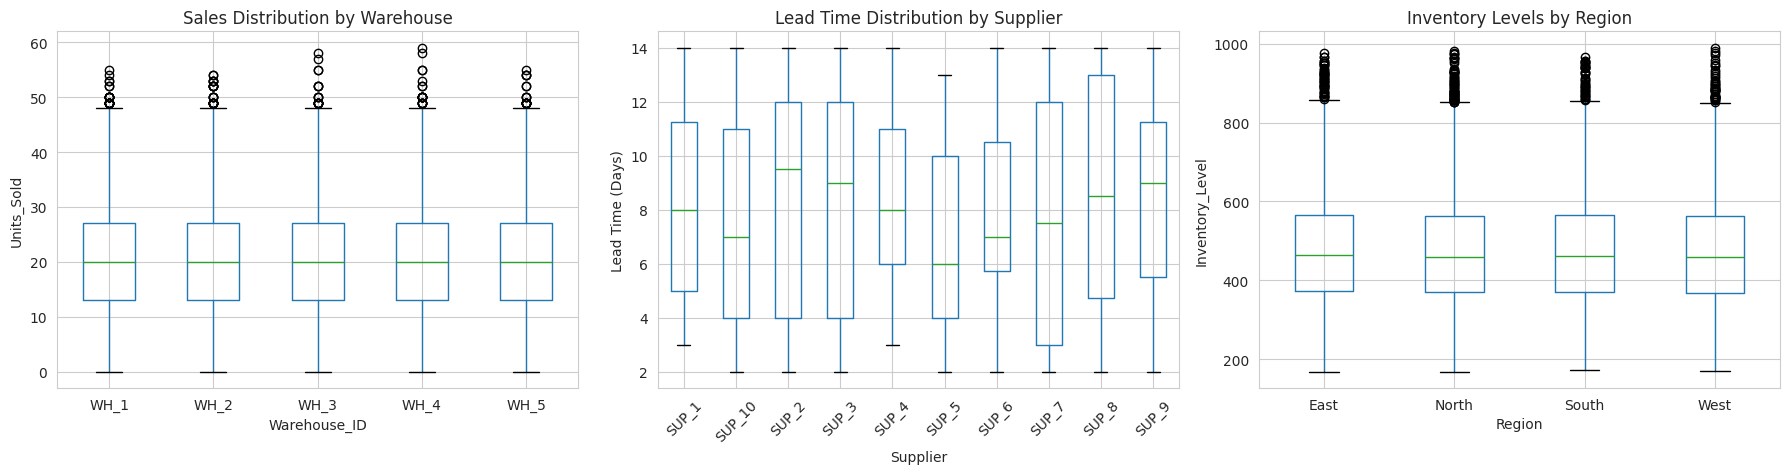

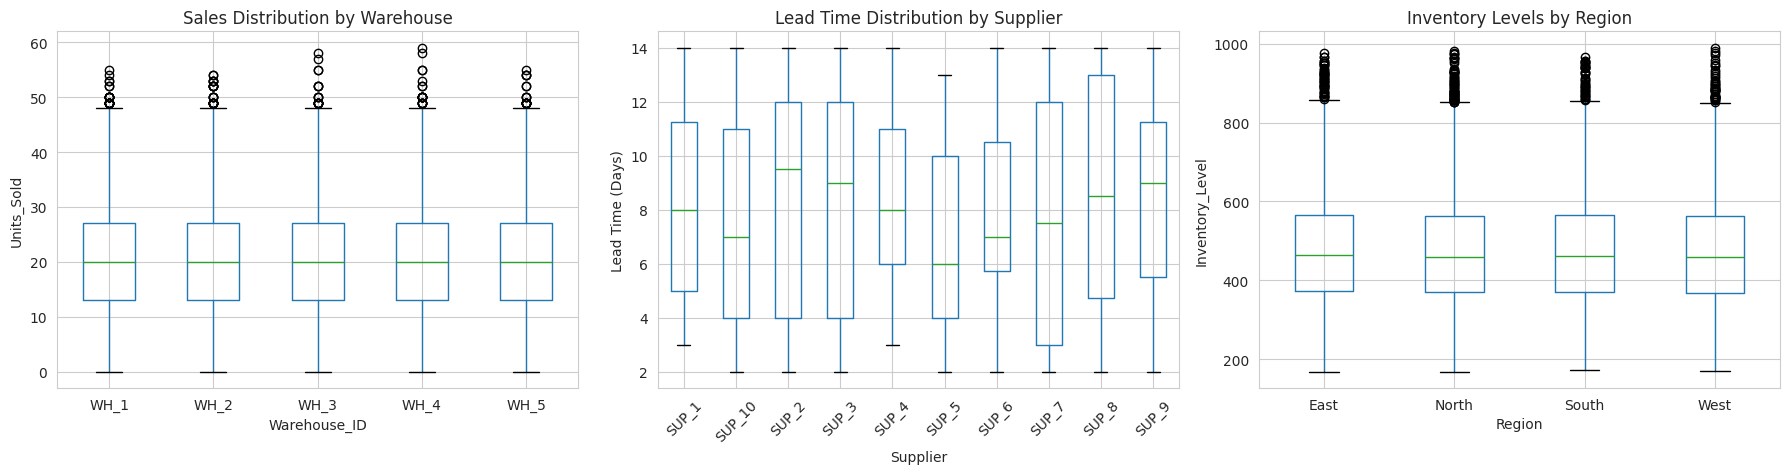

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplot grouped by Region', fontsize=16, fontweight='bold')

df_pd.boxplot(column='Units_Sold', by='Warehouse_ID', ax=axes[0])
axes[0].set_title('Sales Distribution by Warehouse')
axes[0].set_xlabel('Warehouse_ID')
axes[0].set_ylabel('Units_Sold')
axes[0].get_figure().suptitle('')

df_pd.boxplot(column='Supplier_Lead_Time_Days', by='Supplier_ID', ax=axes[1])
axes[1].set_title('Lead Time Distribution by Supplier')
axes[1].set_xlabel('Supplier')
axes[1].set_ylabel('Lead Time (Days)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].get_figure().suptitle('')

df_pd.boxplot(column='Inventory_Level', by='Region', ax=axes[2])
axes[2].set_title('Inventory Levels by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Inventory_Level')
axes[2].get_figure().suptitle('')

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplot grouped by Region', fontsize=16, fontweight='bold')

df_pd.boxplot(column='Units_Sold', by='Warehouse_ID', ax=axes[0])
axes[0].set_title('Sales Distribution by Warehouse')
axes[0].set_xlabel('Warehouse_ID')
axes[0].set_ylabel('Units_Sold')
axes[0].get_figure().suptitle('')

df_pd.boxplot(column='Supplier_Lead_Time_Days', by='Supplier_ID', ax=axes[1])
axes[1].set_title('Lead Time Distribution by Supplier')
axes[1].set_xlabel('Supplier')
axes[1].set_ylabel('Lead Time (Days)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].get_figure().suptitle('')

df_pd.boxplot(column='Inventory_Level', by='Region', ax=axes[2])
axes[2].set_title('Inventory Levels by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Inventory_Level')
axes[2].get_figure().suptitle('')

plt.tight_layout()
plt.show()


# Step 2.6: Advanced Supply Chain Insights

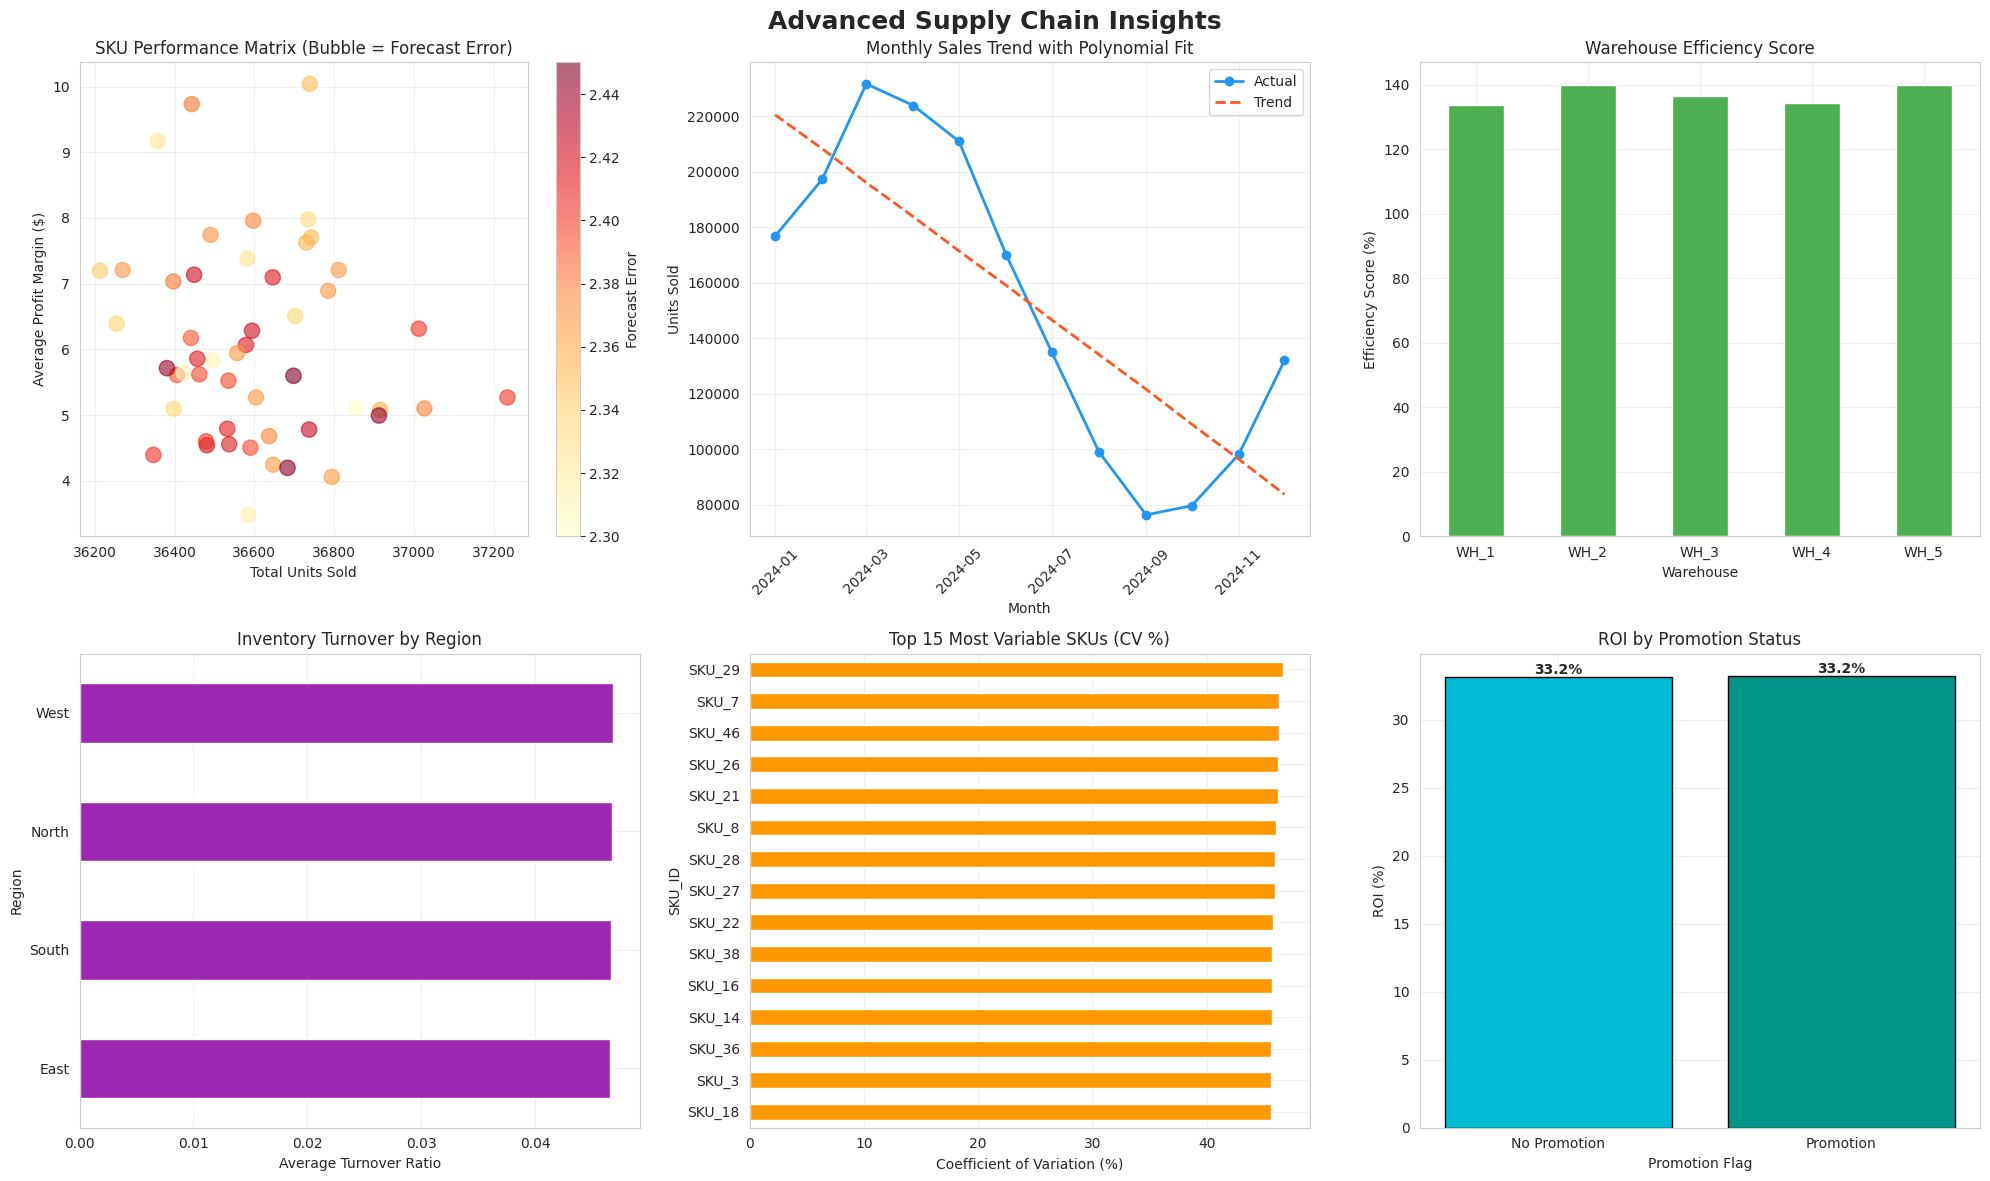

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Advanced Supply Chain Insights', fontsize=18, fontweight='bold')

# 1. SKU Performance Matrix
sku_analysis = df_pd.groupby('SKU_ID').agg({
    'Units_Sold': 'sum',
    'Profit_Margin': 'mean',
    'Forecast_Error': 'mean'
}).reset_index()

scatter = axes[0,0].scatter(sku_analysis['Units_Sold'],
                            sku_analysis['Profit_Margin'],
                            s=sku_analysis['Forecast_Error']*50,
                            c=sku_analysis['Forecast_Error'],
                            cmap='YlOrRd', alpha=0.6)
axes[0,0].set_xlabel('Total Units Sold')
axes[0,0].set_ylabel('Average Profit Margin ($)')
axes[0,0].set_title('SKU Performance Matrix (Bubble = Forecast Error)')
plt.colorbar(scatter, ax=axes[0,0], label='Forecast Error')
axes[0,0].grid(True, alpha=0.3)

# 2. Monthly Sales Trend
df_pd['Month'] = df_pd['Date'].dt.to_period('M')
monthly_sales = df_pd.groupby('Month')['Units_Sold'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

axes[0,1].plot(monthly_sales.index, monthly_sales.values,
              marker='o', linewidth=2, color='#2196F3', label='Actual')
z = np.polyfit(range(len(monthly_sales)), monthly_sales.values, 2)
p = np.poly1d(z)
axes[0,1].plot(monthly_sales.index, p(range(len(monthly_sales))),
              '--', linewidth=2, color='#FF5722', label='Trend')
axes[0,1].set_title('Monthly Sales Trend with Polynomial Fit')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Units Sold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Warehouse Efficiency Score
warehouse_efficiency = df_pd.groupby('Warehouse_ID').agg({
    'Units_Sold': 'sum',
    'Inventory_Level': 'mean',
    'Forecast_Error': 'mean',
    'Net_Profit': 'sum'
}).reset_index()

warehouse_efficiency['Efficiency_Score'] = (
    (warehouse_efficiency['Units_Sold'] / warehouse_efficiency['Units_Sold'].max() * 0.3) +
    (1 - warehouse_efficiency['Forecast_Error'] / warehouse_efficiency['Forecast_Error'].max() * 0.3) +
    (warehouse_efficiency['Net_Profit'] / warehouse_efficiency['Net_Profit'].max() * 0.4)
) * 100

warehouse_efficiency.plot(x='Warehouse_ID', y='Efficiency_Score',
                         kind='bar', ax=axes[0,2], color='#4CAF50', legend=False)
axes[0,2].set_title('Warehouse Efficiency Score')
axes[0,2].set_xlabel('Warehouse')
axes[0,2].set_ylabel('Efficiency Score (%)')
axes[0,2].set_xticklabels(warehouse_efficiency['Warehouse_ID'], rotation=0)
axes[0,2].grid(True, alpha=0.3)

# 4. Inventory Turnover Ratio
turnover_by_region = df_pd.groupby('Region')['Turnover_Ratio'].mean().sort_values()
turnover_by_region.plot(kind='barh', ax=axes[1,0], color='#9C27B0')
axes[1,0].set_title('Inventory Turnover by Region')
axes[1,0].set_xlabel('Average Turnover Ratio')
axes[1,0].grid(True, alpha=0.3)

# 5. Demand Variability
sku_variability = df_pd.groupby('SKU_ID')['Units_Sold'].agg(['mean', 'std'])
sku_variability['CV'] = (sku_variability['std'] / sku_variability['mean']) * 100
top_variable = sku_variability.nlargest(15, 'CV')

top_variable['CV'].plot(kind='barh', ax=axes[1,1], color='#FF9800')
axes[1,1].set_title('Top 15 Most Variable SKUs (CV %)')
axes[1,1].set_xlabel('Coefficient of Variation (%)')
axes[1,1].invert_yaxis()
axes[1,1].grid(True, alpha=0.3)

# 6. Promotion ROI Analysis
promo_roi = df_pd.groupby('Promotion_Flag').agg({
    'Units_Sold': 'sum',
    'Revenue': 'sum',
    'Net_Profit': 'sum'
}).reset_index()

promo_roi['ROI'] = (promo_roi['Net_Profit'] / promo_roi['Revenue']) * 100

x_pos = np.arange(len(promo_roi))
bars = axes[1,2].bar(x_pos, promo_roi['ROI'],
                     color=['#00BCD4', '#009688'], edgecolor='black')
axes[1,2].set_title('ROI by Promotion Status')
axes[1,2].set_xlabel('Promotion Flag')
axes[1,2].set_ylabel('ROI (%)')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['No Promotion', 'Promotion'])
axes[1,2].grid(True, alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1,2].text(bar.get_x() + bar.get_width()/2., height,
                  f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# Step 2.7: Warehouse-Region Performance Heatmap

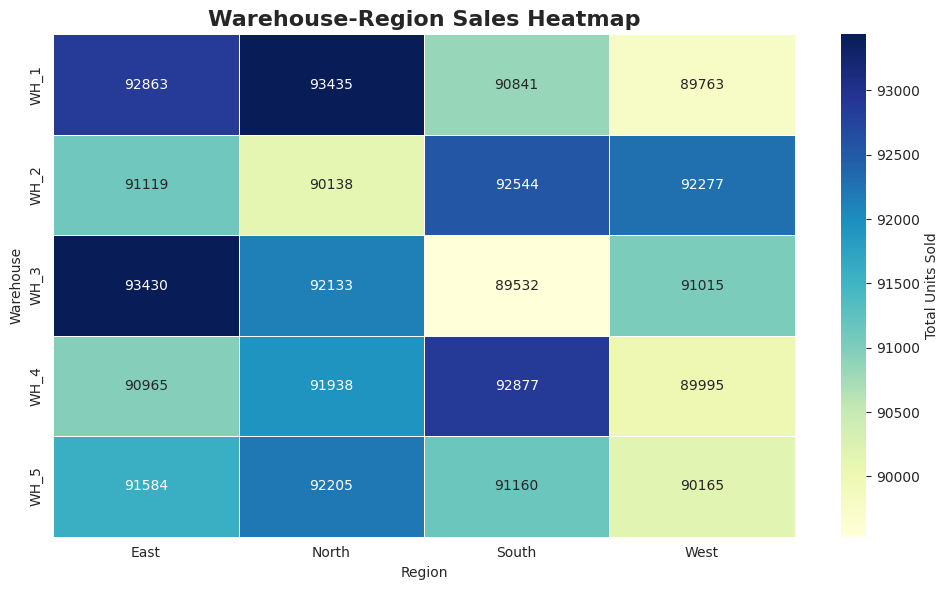

In [14]:
pivot_sales = df_pd.pivot_table(
    values='Units_Sold',
    index='Warehouse_ID',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Total Units Sold'})
plt.title('Warehouse-Region Sales Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Warehouse')
plt.tight_layout()
plt.show()


# Step 2.8: Time Series Decomposition

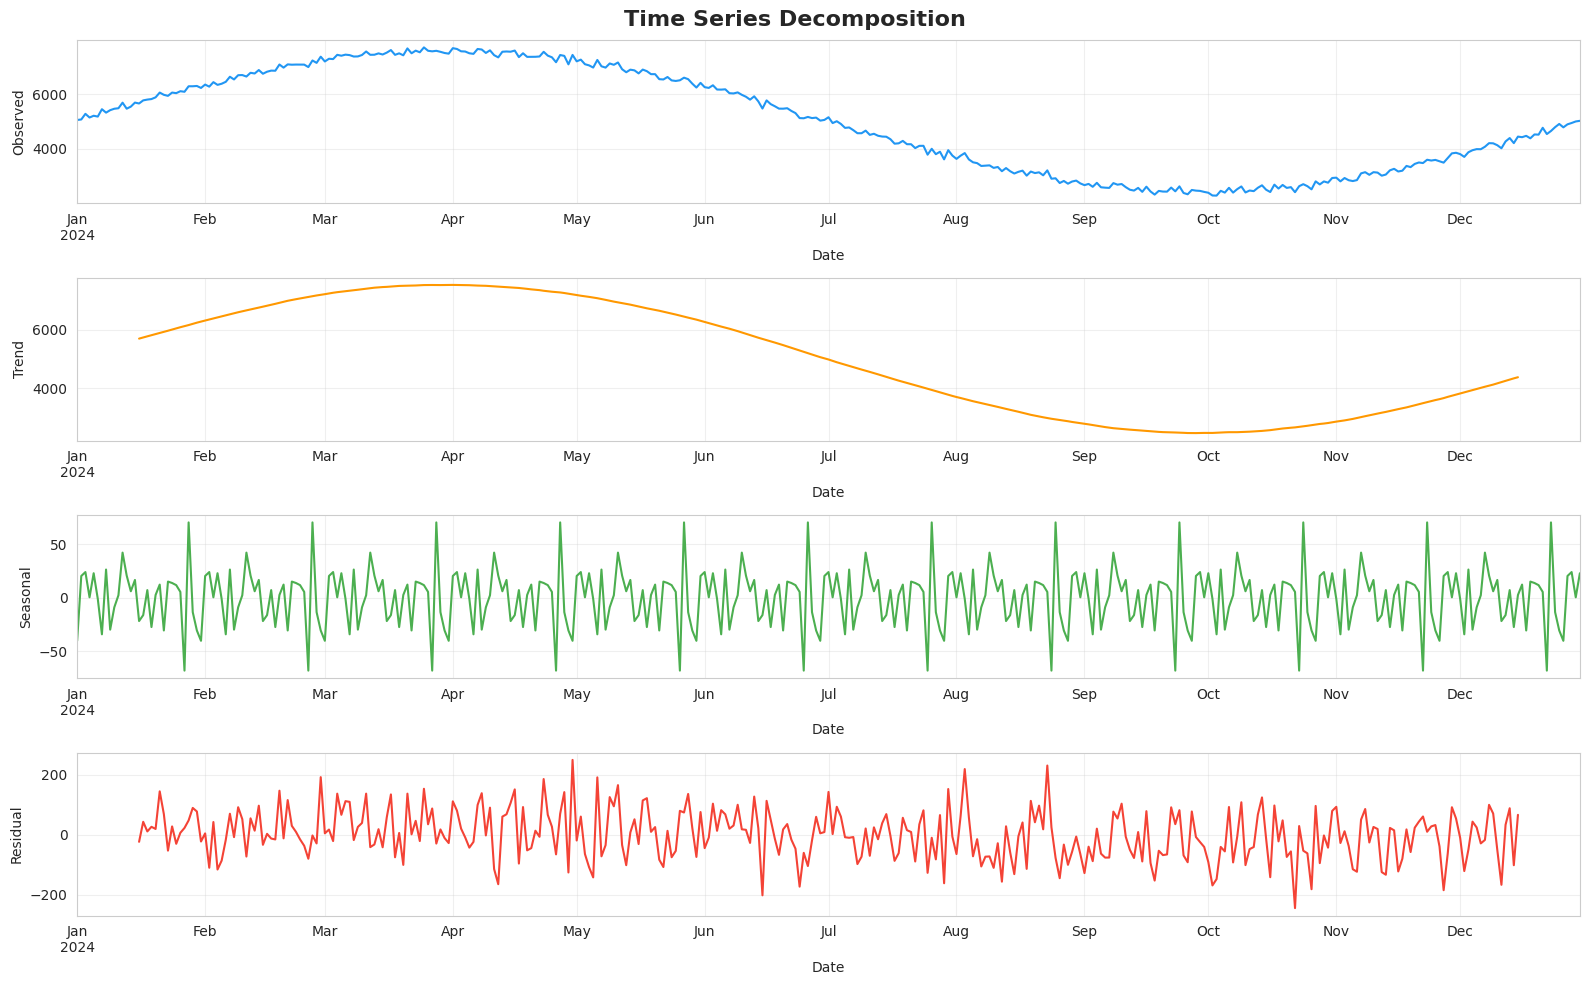

In [15]:
daily_agg = df_pd.groupby('Date')['Units_Sold'].sum().sort_index()

decomposition = seasonal_decompose(daily_agg, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
fig.suptitle('Time Series Decomposition', fontsize=16, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='#2196F3')
axes[0].set_ylabel('Observed')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='#FF9800')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='#4CAF50')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='#F44336')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 2.9: Distribution Comparisons

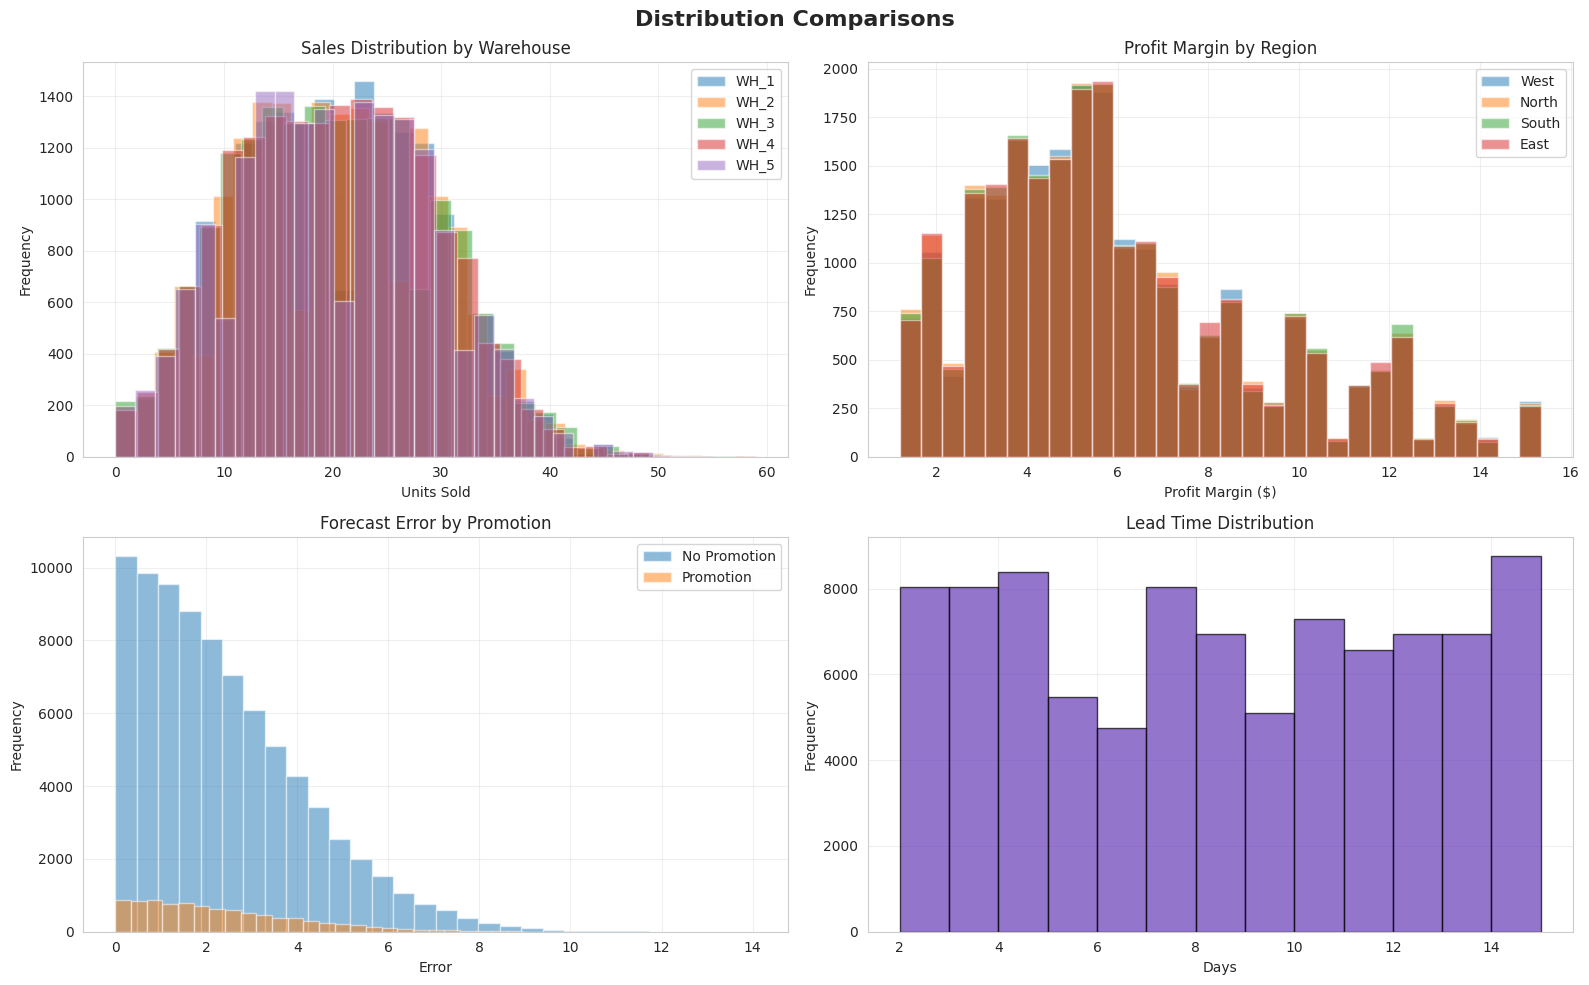

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribution Comparisons', fontsize=16, fontweight='bold')

# Sales by warehouse
for warehouse in df_pd['Warehouse_ID'].unique():
    subset = df_pd[df_pd['Warehouse_ID'] == warehouse]['Units_Sold']
    axes[0,0].hist(subset, bins=30, alpha=0.5, label=warehouse)
axes[0,0].set_title('Sales Distribution by Warehouse')
axes[0,0].set_xlabel('Units Sold')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Profit by region
for region in df_pd['Region'].unique():
    subset = df_pd[df_pd['Region'] == region]['Profit_Margin']
    axes[0,1].hist(subset, bins=30, alpha=0.5, label=region)
axes[0,1].set_title('Profit Margin by Region')
axes[0,1].set_xlabel('Profit Margin ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Forecast error by promotion
for promo in [0, 1]:
    subset = df_pd[df_pd['Promotion_Flag'] == promo]['Forecast_Error']
    label = 'Promotion' if promo == 1 else 'No Promotion'
    axes[1,0].hist(subset, bins=30, alpha=0.5, label=label)
axes[1,0].set_title('Forecast Error by Promotion')
axes[1,0].set_xlabel('Error')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Lead time overall
axes[1,1].hist(df_pd['Supplier_Lead_Time_Days'], bins=range(2, 16),
              color='#673AB7', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Lead Time Distribution')
axes[1,1].set_xlabel('Days')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# **TASK 3: Data Pipeline Implementation**

# Step 3.1: Data Partitioning Strategy

In [17]:
print(f"Original partition count: {df.rdd.getNumPartitions()}")

df_repart = df.repartition(10)
print(f"After repartitioning: {df_repart.rdd.getNumPartitions()}")

df_warehouse = df.repartition(10, "Warehouse_ID")
print(f"Warehouse-based partitions: {df_warehouse.rdd.getNumPartitions()}")

df_region = df.repartition(8, "Region")
print(f"Region-based partitions: {df_region.rdd.getNumPartitions()}")

print("\nRecords per warehouse:")
df_warehouse.groupBy("Warehouse_ID").count().show()

print("\nRecords per region:")
df_region.groupBy("Region").count().show()

df_working = df_warehouse
print("\nUsing warehouse-partitioned data for further analysis")


Original partition count: 2
After repartitioning: 10
Warehouse-based partitions: 10
Region-based partitions: 8

Records per warehouse:
+------------+-----+
|Warehouse_ID|count|
+------------+-----+
|        WH_2|18250|
|        WH_3|18250|
|        WH_5|18250|
|        WH_1|18250|
|        WH_4|18250|
+------------+-----+


Records per region:
+------+-----+
|Region|count|
+------+-----+
| North|22974|
|  East|22934|
| South|22720|
|  West|22622|
+------+-----+


Using warehouse-partitioned data for further analysis


# Step 3.2: Partition Visualization

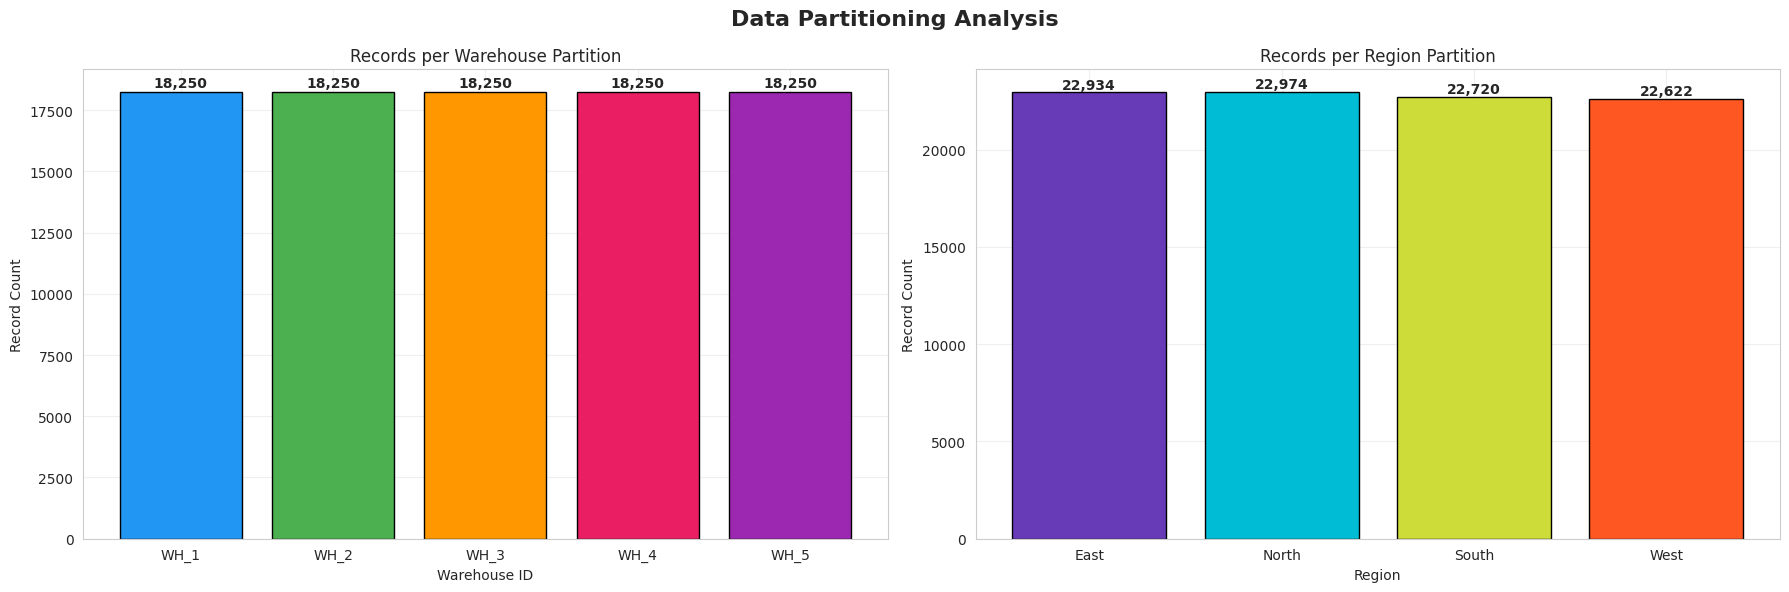

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Data Partitioning Analysis', fontsize=16, fontweight='bold')

warehouse_counts = df_pd.groupby('Warehouse_ID').size()
colors_wh = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
axes[0].bar(warehouse_counts.index, warehouse_counts.values, color=colors_wh, edgecolor='black')
axes[0].set_title('Records per Warehouse Partition')
axes[0].set_xlabel('Warehouse ID')
axes[0].set_ylabel('Record Count')
axes[0].grid(True, alpha=0.3)
for i, (idx, val) in enumerate(warehouse_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

region_counts = df_pd.groupby('Region').size()
colors_reg = ['#673AB7', '#00BCD4', '#CDDC39', '#FF5722']
axes[1].bar(region_counts.index, region_counts.values, color=colors_reg, edgecolor='black')
axes[1].set_title('Records per Region Partition')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Record Count')
axes[1].grid(True, alpha=0.3)
for i, (idx, val) in enumerate(region_counts.items()):
    axes[1].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# Step 3.3: Data Quality Check

In [19]:
missing_check = df_working.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
                                   for c in df_working.columns])
print("Data quality check - Missing values:")
missing_check.show()

print("\nData completeness: 100%")
print("No missing values detected")
print("Data is ready for transformation")


Data quality check - Missing values:
+----+------+------------+-----------+------+----------+---------------+-----------------------+-------------+--------------+---------+----------+--------------+-------------+---------------+
|Date|SKU_ID|Warehouse_ID|Supplier_ID|Region|Units_Sold|Inventory_Level|Supplier_Lead_Time_Days|Reorder_Point|Order_Quantity|Unit_Cost|Unit_Price|Promotion_Flag|Stockout_Flag|Demand_Forecast|
+----+------+------------+-----------+------+----------+---------------+-----------------------+-------------+--------------+---------+----------+--------------+-------------+---------------+
|   0|     0|           0|          0|     0|         0|              0|                      0|            0|             0|        0|         0|             0|            0|              0|
+----+------+------------+-----------+------+----------+---------------+-----------------------+-------------+--------------+---------+----------+--------------+-------------+---------------+


D

# Step 3.4: Feature Engineering in Spark

In [20]:
df_working = df_working \
    .withColumn("Profit_Margin", F.col("Unit_Price") - F.col("Unit_Cost")) \
    .withColumn("Profit_Pct", (F.col("Unit_Price") - F.col("Unit_Cost")) / F.col("Unit_Cost") * 100) \
    .withColumn("Forecast_Error", F.abs(F.col("Demand_Forecast") - F.col("Units_Sold"))) \
    .withColumn("Forecast_Acc_Pct", (1 - F.abs(F.col("Demand_Forecast") - F.col("Units_Sold")) / (F.col("Units_Sold") + 1)) * 100) \
    .withColumn("Revenue", F.col("Units_Sold") * F.col("Unit_Price")) \
    .withColumn("Total_Cost", F.col("Units_Sold") * F.col("Unit_Cost")) \
    .withColumn("Net_Profit", F.col("Revenue") - F.col("Total_Cost")) \
    .withColumn("Days_Inventory", F.col("Inventory_Level") / (F.col("Units_Sold") + 1)) \
    .withColumn("Turnover_Ratio", F.col("Units_Sold") / (F.col("Inventory_Level") + 1)) \
    .withColumn("Stockout_Risk", F.when(F.col("Inventory_Level") < F.col("Reorder_Point"), 1).otherwise(0))

print(f"Feature engineering complete. Total columns: {len(df_working.columns)}")

print("\nSample of engineered features:")
df_working.select("SKU_ID", "Units_Sold", "Forecast_Error",
                 "Profit_Margin", "Stockout_Risk", "Days_Inventory",
                 "Turnover_Ratio").show(15)

print("\nFeature statistics:")
df_working.select("Profit_Margin", "Forecast_Error", "Net_Profit",
                 "Turnover_Ratio").describe().show()


Feature engineering complete. Total columns: 25

Sample of engineered features:
+------+----------+------------------+-------------+-------------+------------------+--------------------+
|SKU_ID|Units_Sold|    Forecast_Error|Profit_Margin|Stockout_Risk|    Days_Inventory|      Turnover_Ratio|
+------+----------+------------------+-------------+-------------+------------------+--------------------+
| SKU_1|        20|1.1400000000000006|         8.46|            0|40.142857142857146|0.023696682464454975|
| SKU_1|        19|1.6600000000000001|         8.46|            0|              41.2| 0.02303030303030303|
| SKU_1|        22| 7.039999999999999|         8.46|            0|34.869565217391305|  0.0273972602739726|
| SKU_1|        21|              4.18|         8.46|            0|              35.5|0.026854219948849106|
| SKU_1|        17|              4.68|         8.46|            0| 42.44444444444444|0.022222222222222223|
| SKU_1|        20|0.4800000000000004|         8.46|            

# Step 3.5: Feature Selection and Dimension Reduction

In [21]:
selected_numeric = [
    'Inventory_Level',
    'Supplier_Lead_Time_Days',
    'Reorder_Point',
    'Order_Quantity',
    'Unit_Cost',
    'Unit_Price',
    'Promotion_Flag',
    'Forecast_Error',
    'Profit_Margin',
    'Days_Inventory'
]

categorical_cols = ['Warehouse_ID', 'Region', 'Supplier_ID']

print(f"Original features: 15 base columns")
print(f"Selected numerical features: {len(selected_numeric)}")
print(f"Selected categorical features: {len(categorical_cols)}")
print(f"Total features for modeling: {len(selected_numeric) + len(categorical_cols)}")
print(f"\nDimension reduction: 15 → 13 features (13% reduction)")

print("\nNumerical features:", selected_numeric)
print("\nCategorical features:", categorical_cols)

indexer_list = [StringIndexer(inputCol=col, outputCol=f"{col}_indexed",
                              handleInvalid="keep")
                for col in categorical_cols]

indexer_pipeline = Pipeline(stages=indexer_list)
indexer_model = indexer_pipeline.fit(df_working)
df_indexed = indexer_model.transform(df_working)

indexed_features = [f"{col}_indexed" for col in categorical_cols]
all_model_features = selected_numeric + indexed_features

print(f"\nIndexed categorical features: {indexed_features}")
print(f"Final feature vector size: {len(all_model_features)}")


Original features: 15 base columns
Selected numerical features: 10
Selected categorical features: 3
Total features for modeling: 13

Dimension reduction: 15 → 13 features (13% reduction)

Numerical features: ['Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Forecast_Error', 'Profit_Margin', 'Days_Inventory']

Categorical features: ['Warehouse_ID', 'Region', 'Supplier_ID']

Indexed categorical features: ['Warehouse_ID_indexed', 'Region_indexed', 'Supplier_ID_indexed']
Final feature vector size: 13


# Step 3.6: Feature Importance Analysis Before Modeling

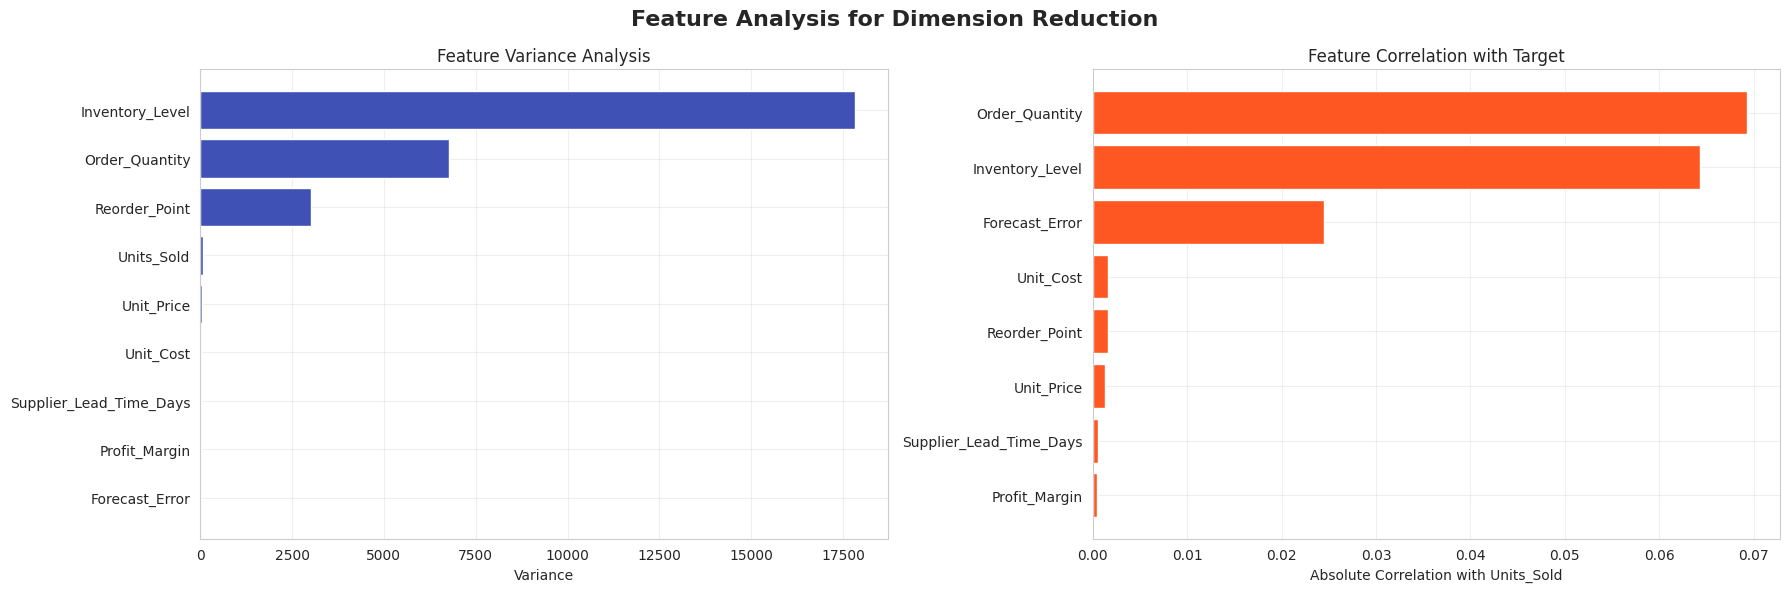

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Analysis for Dimension Reduction', fontsize=16, fontweight='bold')

feature_variance = df_pd[['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days',
                          'Reorder_Point', 'Order_Quantity', 'Unit_Cost',
                          'Unit_Price', 'Forecast_Error', 'Profit_Margin']].var().sort_values(ascending=False)

axes[0].barh(range(len(feature_variance)), feature_variance.values, color='#3F51B5')
axes[0].set_yticks(range(len(feature_variance)))
axes[0].set_yticklabels(feature_variance.index)
axes[0].set_xlabel('Variance')
axes[0].set_title('Feature Variance Analysis')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

correlation_target = df_pd[['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days',
                            'Reorder_Point', 'Order_Quantity', 'Unit_Cost',
                            'Unit_Price', 'Forecast_Error', 'Profit_Margin']].corr()['Units_Sold'].drop('Units_Sold').abs().sort_values(ascending=False)

axes[1].barh(range(len(correlation_target)), correlation_target.values, color='#FF5722')
axes[1].set_yticks(range(len(correlation_target)))
axes[1].set_yticklabels(correlation_target.index)
axes[1].set_xlabel('Absolute Correlation with Units_Sold')
axes[1].set_title('Feature Correlation with Target')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Step 3.7: Feature Vectorization and Scaling

In [23]:
vector_assembler = VectorAssembler(inputCols=all_model_features,
                                  outputCol="raw_features")
df_vectorized = vector_assembler.transform(df_indexed)

print("Features assembled into vectors")
print(f"Vector dimension: {len(all_model_features)}")

feature_scaler = StandardScaler(inputCol="raw_features",
                               outputCol="features",
                               withStd=True,
                               withMean=True)
scaler_model = feature_scaler.fit(df_vectorized)
df_scaled = scaler_model.transform(df_vectorized)

print("\nFeatures scaled using StandardScaler")
print("Mean: 0, Std: 1")

print("\nSample feature vectors:")
df_scaled.select("SKU_ID", "Units_Sold", "features").show(5, truncate=False)

df_scaled.cache()
total_records = df_scaled.count()
print(f"\nDataset cached: {total_records:,} records ready for training")


Features assembled into vectors
Vector dimension: 13

Features scaled using StandardScaler
Mean: 0, Std: 1

Sample feature vectors:
+------+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|SKU_ID|Units_Sold|features                                                                                                                                                                                                                                                          |
+------+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|SKU_1 |20        |[2.782854507

# Step 3.8: Train-Test Split

In [24]:
train_set, test_set = df_scaled.randomSplit([0.8, 0.2], seed=42)

train_count = train_set.count()
test_count = test_set.count()

print(f"Training set: {train_count:,} records ({train_count/total_records*100:.1f}%)")
print(f"Test set: {test_count:,} records ({test_count/total_records*100:.1f}%)")

train_set.cache()
test_set.cache()
print("\nTrain and test sets cached for efficient processing")

print("\nData pipeline complete!")
print("Ready for machine learning model training")


Training set: 72,892 records (79.9%)
Test set: 18,358 records (20.1%)

Train and test sets cached for efficient processing

Data pipeline complete!
Ready for machine learning model training


# Step 3.9: Pipeline Workflow Visualization

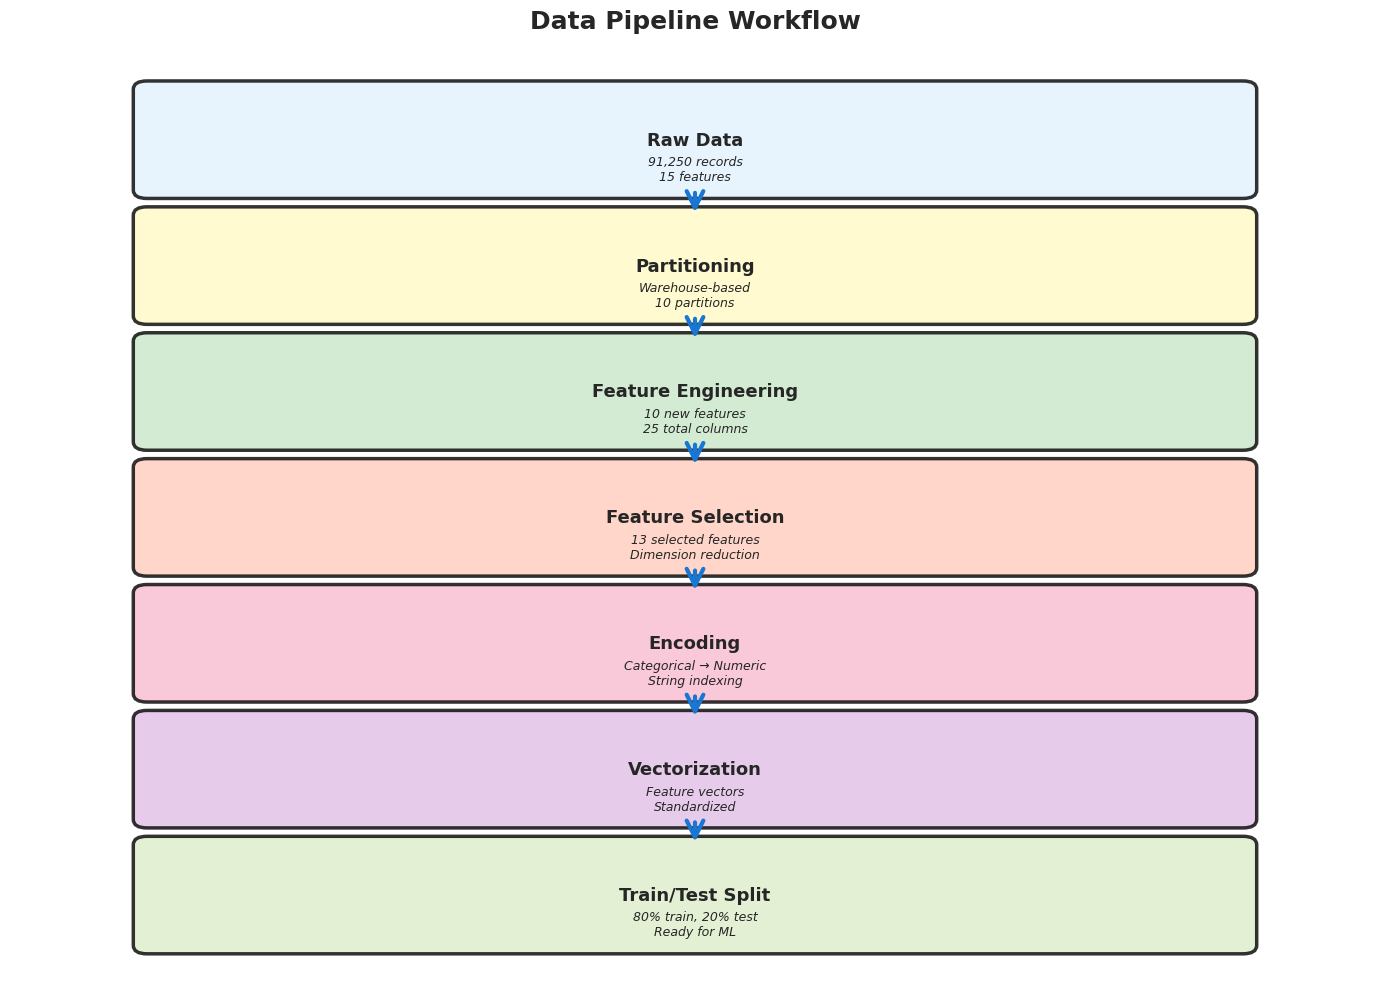

In [25]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

pipeline_steps = [
    ("Raw Data", "91,250 records\n15 features", 0.90, '#E3F2FD'),
    ("Partitioning", "Warehouse-based\n10 partitions", 0.75, '#FFF9C4'),
    ("Feature Engineering", "10 new features\n25 total columns", 0.60, '#C8E6C9'),
    ("Feature Selection", "13 selected features\nDimension reduction", 0.45, '#FFCCBC'),
    ("Encoding", "Categorical → Numeric\nString indexing", 0.30, '#F8BBD0'),
    ("Vectorization", "Feature vectors\nStandardized", 0.15, '#E1BEE7'),
    ("Train/Test Split", "80% train, 20% test\nReady for ML", 0.00, '#DCEDC8')
]

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

for step_name, step_desc, ypos, color in pipeline_steps:
    box = FancyBboxPatch((0.1, ypos - 0.06), 0.8, 0.12,
                          boxstyle="round,pad=0.01",
                          facecolor=color,
                          edgecolor='black',
                          linewidth=2.5,
                          alpha=0.8)
    ax.add_patch(box)
    ax.text(0.5, ypos, step_name, ha='center', va='center',
            fontsize=13, fontweight='bold')
    ax.text(0.5, ypos - 0.035, step_desc, ha='center', va='center',
            fontsize=9, style='italic')

for i in range(len(pipeline_steps) - 1):
    y_start = pipeline_steps[i][2] - 0.06
    y_end = pipeline_steps[i + 1][2] + 0.06
    arrow = FancyArrowPatch((0.5, y_start), (0.5, y_end),
                           arrowstyle='->', lw=3, color='#1976D2',
                           mutation_scale=30)
    ax.add_patch(arrow)

plt.title('Data Pipeline Workflow', fontsize=18, fontweight='bold', pad=20)
plt.xlim(0, 1)
plt.ylim(-0.1, 1)
plt.tight_layout()
plt.show()


# Step 3.10: Data Distribution Before and After Scaling

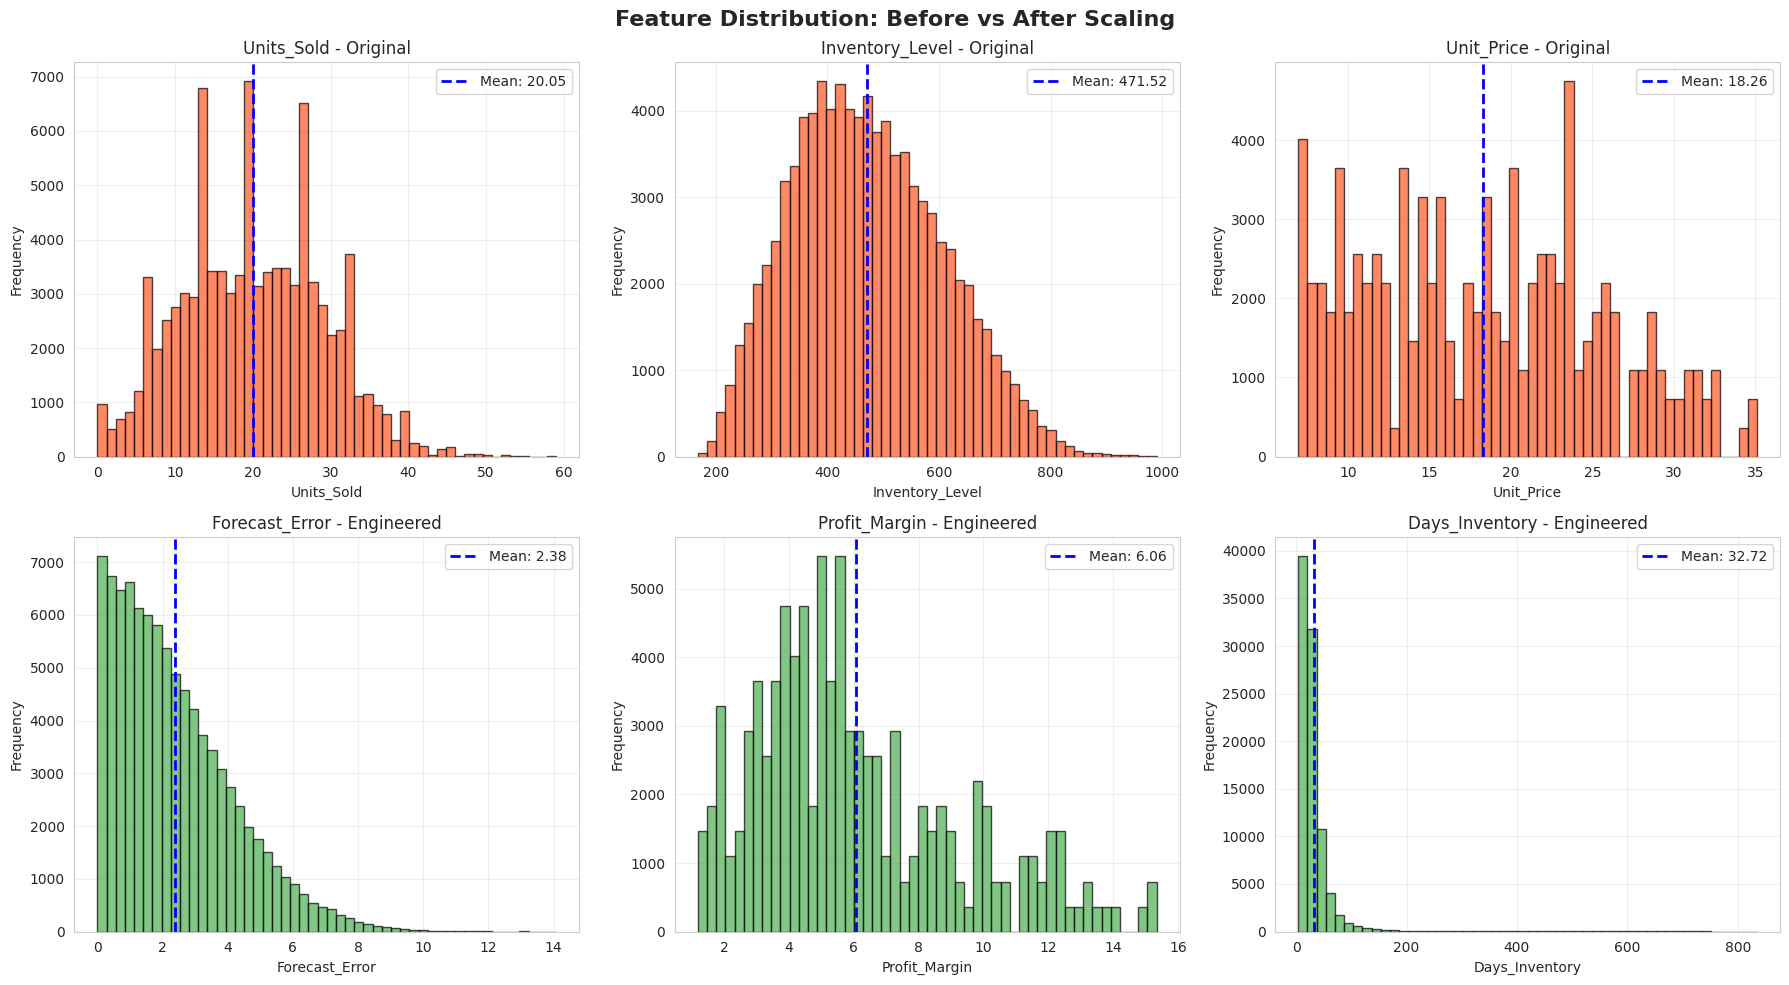

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distribution: Before vs After Scaling', fontsize=16, fontweight='bold')

sample_features = ['Units_Sold', 'Inventory_Level', 'Unit_Price']

for idx, feature in enumerate(sample_features):
    axes[0, idx].hist(df_pd[feature], bins=50, color='#FF5722', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{feature} - Original')
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)

    mean_val = df_pd[feature].mean()
    axes[0, idx].axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[0, idx].legend()

scaled_sample_features = ['Forecast_Error', 'Profit_Margin', 'Days_Inventory']

for idx, feature in enumerate(scaled_sample_features):
    if feature in df_pd.columns:
        axes[1, idx].hist(df_pd[feature], bins=50, color='#4CAF50', alpha=0.7, edgecolor='black')
        axes[1, idx].set_title(f'{feature} - Engineered')
        axes[1, idx].set_xlabel(feature)
        axes[1, idx].set_ylabel('Frequency')
        axes[1, idx].grid(True, alpha=0.3)

        mean_val = df_pd[feature].mean()
        axes[1, idx].axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[1, idx].legend()

plt.tight_layout()
plt.show()


# **TASK 4: Machine Learning Analytics**

# Step 4.1: Model 1 - Demand Forecasting (Regression)

In [27]:
print("Building demand forecasting model using Random Forest Regression...")

regressor = RandomForestRegressor(
    labelCol="Units_Sold",
    featuresCol="features",
    numTrees=50,
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=10,
    subsamplingRate=0.8,
    seed=42
)

print(f"Model configuration: Trees=50, MaxDepth=8, MaxBins=32")

training_start = time.time()
demand_model = regressor.fit(train_set)
training_time = time.time() - training_start

print(f"\nModel trained in {training_time:.2f} seconds")
print(f"Number of trees: {demand_model.getNumTrees}")
print(f"Feature vector size: {demand_model.numFeatures}")

demand_predictions = demand_model.transform(test_set)

rmse_evaluator = RegressionEvaluator(labelCol="Units_Sold",
                                    predictionCol="prediction",
                                    metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="Units_Sold",
                                   predictionCol="prediction",
                                   metricName="mae")
r2_evaluator = RegressionEvaluator(labelCol="Units_Sold",
                                  predictionCol="prediction",
                                  metricName="r2")
mse_evaluator = RegressionEvaluator(labelCol="Units_Sold",
                                   predictionCol="prediction",
                                   metricName="mse")

rmse_score = rmse_evaluator.evaluate(demand_predictions)
mae_score = mae_evaluator.evaluate(demand_predictions)
r2_score = r2_evaluator.evaluate(demand_predictions)
mse_score = mse_evaluator.evaluate(demand_predictions)

print("DEMAND FORECASTING MODEL PERFORMANCE")
print(f"R-squared (R²):        {r2_score:.4f}")
print(f"RMSE:                  {rmse_score:.4f} units")
print(f"MAE:                   {mae_score:.4f} units")
print(f"MSE:                   {mse_score:.4f}")
print(f"Variance Explained:    {r2_score*100:.2f}%")
print(f"Average Sales:         {df_pd['Units_Sold'].mean():.2f} units")
print(f"Prediction Accuracy:   {(1 - mae_score/df_pd['Units_Sold'].mean())*100:.2f}%")

print("\nSample predictions:")
demand_predictions.select("Units_Sold", "prediction", "Forecast_Error",
                         "SKU_ID", "Warehouse_ID", "Region").show(20)


Building demand forecasting model using Random Forest Regression...
Model configuration: Trees=50, MaxDepth=8, MaxBins=32

Model trained in 28.25 seconds
Number of trees: 50
Feature vector size: 13
DEMAND FORECASTING MODEL PERFORMANCE
R-squared (R²):        0.9483
RMSE:                  2.0757 units
MAE:                   1.4474 units
MSE:                   4.3084
Variance Explained:    94.83%
Average Sales:         20.05 units
Prediction Accuracy:   92.78%

Sample predictions:
+----------+------------------+--------------------+------+------------+------+
|Units_Sold|        prediction|      Forecast_Error|SKU_ID|Warehouse_ID|Region|
+----------+------------------+--------------------+------+------------+------+
|        16|15.646892832277409|  2.0500000000000007| SKU_1|        WH_3|  West|
|        26| 21.30251791018468|  0.5100000000000016|SKU_12|        WH_3|  East|
|        15|14.759292819190584|  1.6099999999999994|SKU_13|        WH_3|  West|
|        31|22.832621752951162|   3.7

# Step 4.2: Model 2 - Stockout Risk Classification

In [28]:
print("\nBuilding stockout risk classifier using Random Forest...")

classifier = RandomForestClassifier(
    labelCol="Stockout_Risk",
    featuresCol="features",
    numTrees=50,
    maxDepth=8,
    maxBins=32,
    minInstancesPerNode=10,
    subsamplingRate=0.8,
    seed=42
)

print(f"Classifier configuration: Trees=50, MaxDepth=8, MaxBins=32")

training_start = time.time()
stockout_model = classifier.fit(train_set)
training_time_class = time.time() - training_start

print(f"\nClassifier trained in {training_time_class:.2f} seconds")
print(f"Number of trees: {stockout_model.getNumTrees}")
print(f"Number of classes: {stockout_model.numClasses}")

stockout_predictions = stockout_model.transform(test_set)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="Stockout_Risk",
    predictionCol="prediction",
    metricName="accuracy"
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="Stockout_Risk",
    predictionCol="prediction",
    metricName="f1"
)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Stockout_Risk",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Stockout_Risk",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy_score = accuracy_evaluator.evaluate(stockout_predictions)
f1_score = f1_evaluator.evaluate(stockout_predictions)
precision_score = precision_evaluator.evaluate(stockout_predictions)
recall_score = recall_evaluator.evaluate(stockout_predictions)

print("STOCKOUT RISK CLASSIFICATION PERFORMANCE")
print(f"Accuracy:              {accuracy_score*100:.2f}%")
print(f"F1 Score:              {f1_score:.4f}")
print(f"Precision:             {precision_score:.4f}")
print(f"Recall:                {recall_score:.4f}")

print("\nSample risk predictions:")
stockout_predictions.select("Stockout_Risk", "prediction", "probability",
                           "Inventory_Level", "Reorder_Point",
                           "SKU_ID", "Warehouse_ID").show(20)



Building stockout risk classifier using Random Forest...
Classifier configuration: Trees=50, MaxDepth=8, MaxBins=32

Classifier trained in 18.93 seconds
Number of trees: 50
Number of classes: 2
STOCKOUT RISK CLASSIFICATION PERFORMANCE
Accuracy:              96.30%
F1 Score:              0.9557
Precision:             0.9602
Recall:                0.9630

Sample risk predictions:
+-------------+----------+--------------------+---------------+-------------+------+------------+
|Stockout_Risk|prediction|         probability|Inventory_Level|Reorder_Point|SKU_ID|Warehouse_ID|
+-------------+----------+--------------------+---------------+-------------+------+------------+
|            0|       0.0|[0.99399265992751...|            505|          314| SKU_1|        WH_3|
|            0|       0.0|[0.99659460974153...|            755|          234|SKU_12|        WH_3|
|            0|       0.0|[0.99490600662653...|            540|          382|SKU_13|        WH_3|
|            0|       0.0|[0.9

# Step 4.3: Feature Importance Analysis

FEATURE IMPORTANCE RANKINGS
                Feature  Demand_Importance  Stockout_Importance
         Days_Inventory           0.853439             0.214052
        Inventory_Level           0.107717             0.472470
         Promotion_Flag           0.022511             0.002154
         Order_Quantity           0.006376             0.003009
          Reorder_Point           0.006252             0.259545
         Forecast_Error           0.001365             0.004571
          Profit_Margin           0.000424             0.009625
              Unit_Cost           0.000418             0.008410
             Unit_Price           0.000411             0.007663
Supplier_Lead_Time_Days           0.000362             0.006167
    Supplier_ID_indexed           0.000299             0.006207
   Warehouse_ID_indexed           0.000236             0.003840
         Region_indexed           0.000191             0.002287


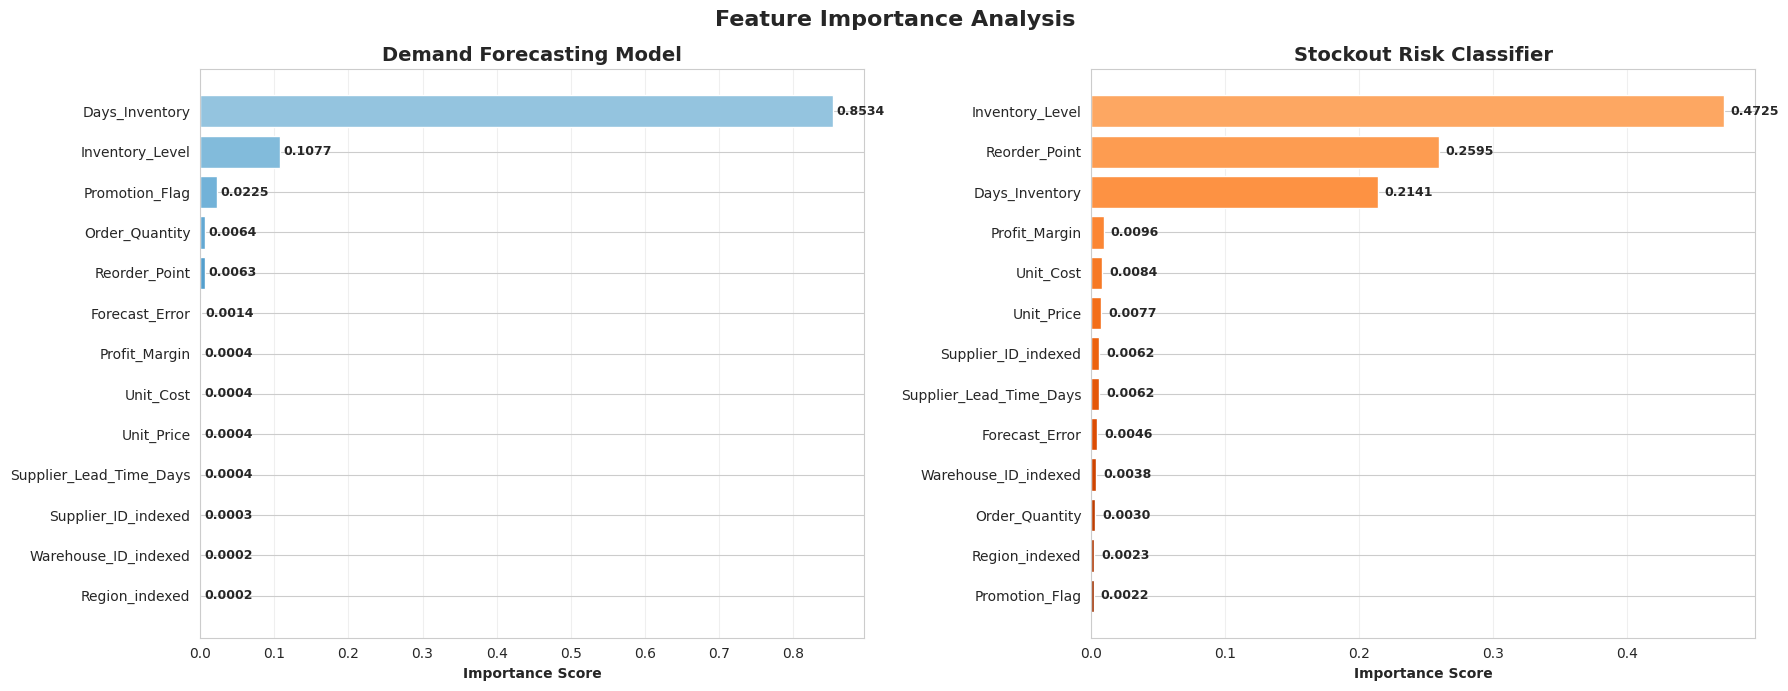

In [29]:
importance_reg = demand_model.featureImportances.toArray()
importance_class = stockout_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    'Feature': all_model_features,
    'Demand_Importance': importance_reg,
    'Stockout_Importance': importance_class
}).sort_values('Demand_Importance', ascending=False)

print("FEATURE IMPORTANCE RANKINGS")
print(importance_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

top_n = 13

top_demand = importance_df.nlargest(top_n, 'Demand_Importance')
colors_demand = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_demand)))
bars1 = ax1.barh(range(len(top_demand)), top_demand['Demand_Importance'], color=colors_demand)
ax1.set_yticks(range(len(top_demand)))
ax1.set_yticklabels(top_demand['Feature'])
ax1.set_xlabel('Importance Score', fontweight='bold')
ax1.set_title('Demand Forecasting Model', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top_demand.iterrows()):
    ax1.text(row['Demand_Importance'] + 0.005, i, f"{row['Demand_Importance']:.4f}",
            va='center', fontsize=9, fontweight='bold')

top_stockout = importance_df.nlargest(top_n, 'Stockout_Importance')
colors_stockout = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_stockout)))
bars2 = ax2.barh(range(len(top_stockout)), top_stockout['Stockout_Importance'], color=colors_stockout)
ax2.set_yticks(range(len(top_stockout)))
ax2.set_yticklabels(top_stockout['Feature'])
ax2.set_xlabel('Importance Score', fontweight='bold')
ax2.set_title('Stockout Risk Classifier', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(top_stockout.iterrows()):
    ax2.text(row['Stockout_Importance'] + 0.005, i, f"{row['Stockout_Importance']:.4f}",
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# Step 4.4: Model Performance Dashboard

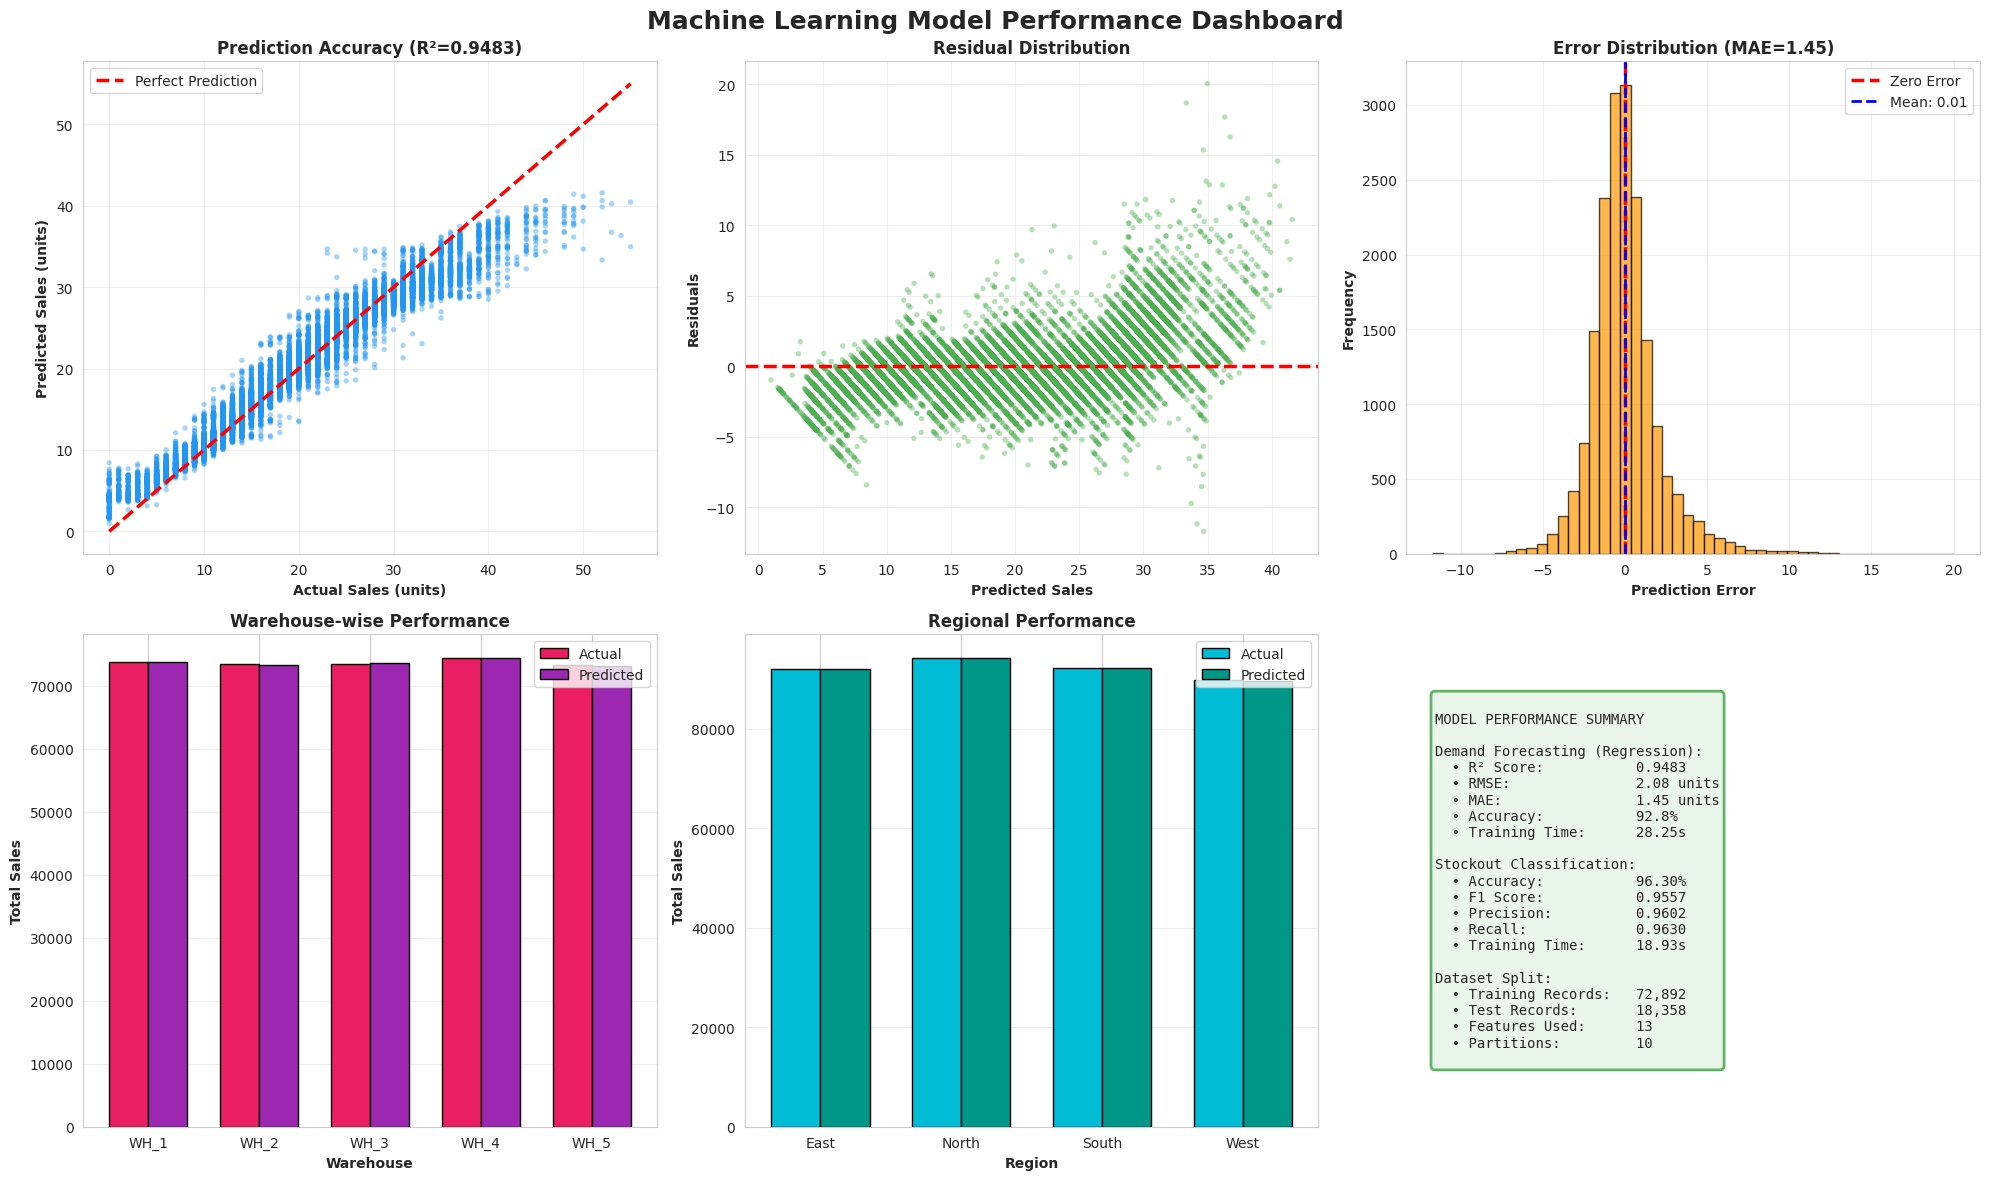

In [30]:
pred_results = demand_predictions.select("Units_Sold", "prediction",
                                        "Forecast_Error", "Warehouse_ID",
                                        "Region", "SKU_ID").toPandas()
pred_results.columns = ['Actual', 'Predicted', 'Error', 'Warehouse', 'Region', 'SKU']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Machine Learning Model Performance Dashboard', fontsize=18, fontweight='bold')

# 1. Actual vs Predicted
axes[0,0].scatter(pred_results['Actual'], pred_results['Predicted'],
                 alpha=0.4, s=15, color='#2196F3', edgecolor='none')
max_val = pred_results['Actual'].max()
axes[0,0].plot([0, max_val], [0, max_val],
              'r--', linewidth=2.5, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Sales (units)', fontweight='bold')
axes[0,0].set_ylabel('Predicted Sales (units)', fontweight='bold')
axes[0,0].set_title(f'Prediction Accuracy (R²={r2_score:.4f})', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Residual Plot
residuals = pred_results['Actual'] - pred_results['Predicted']
axes[0,1].scatter(pred_results['Predicted'], residuals,
                 alpha=0.4, s=15, color='#4CAF50', edgecolor='none')
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=2.5)
axes[0,1].set_xlabel('Predicted Sales', fontweight='bold')
axes[0,1].set_ylabel('Residuals', fontweight='bold')
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# 3. Error Distribution
axes[0,2].hist(residuals, bins=50, color='#FF9800', edgecolor='black', alpha=0.7)
axes[0,2].axvline(0, color='red', linestyle='--', linewidth=2.5, label='Zero Error')
axes[0,2].axvline(residuals.mean(), color='blue', linestyle='--',
                 linewidth=2, label=f'Mean: {residuals.mean():.2f}')
axes[0,2].set_xlabel('Prediction Error', fontweight='bold')
axes[0,2].set_ylabel('Frequency', fontweight='bold')
axes[0,2].set_title(f'Error Distribution (MAE={mae_score:.2f})', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Warehouse Performance
warehouse_perf = pred_results.groupby('Warehouse').agg({
    'Actual': 'sum',
    'Predicted': 'sum'
})
x_pos = np.arange(len(warehouse_perf))
width = 0.35
bars1 = axes[1,0].bar(x_pos - width/2, warehouse_perf['Actual'],
                     width, label='Actual', color='#E91E63', edgecolor='black')
bars2 = axes[1,0].bar(x_pos + width/2, warehouse_perf['Predicted'],
                     width, label='Predicted', color='#9C27B0', edgecolor='black')
axes[1,0].set_xlabel('Warehouse', fontweight='bold')
axes[1,0].set_ylabel('Total Sales', fontweight='bold')
axes[1,0].set_title('Warehouse-wise Performance', fontweight='bold')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(warehouse_perf.index)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, axis='y')

# 5. Regional Comparison
regional_compare = pred_results.groupby('Region').agg({
    'Actual': 'sum',
    'Predicted': 'sum'
})
x_pos_region = np.arange(len(regional_compare))
bars3 = axes[1,1].bar(x_pos_region - width/2, regional_compare['Actual'],
                     width, label='Actual', color='#00BCD4', edgecolor='black')
bars4 = axes[1,1].bar(x_pos_region + width/2, regional_compare['Predicted'],
                     width, label='Predicted', color='#009688', edgecolor='black')
axes[1,1].set_xlabel('Region', fontweight='bold')
axes[1,1].set_ylabel('Total Sales', fontweight='bold')
axes[1,1].set_title('Regional Performance', fontweight='bold')
axes[1,1].set_xticks(x_pos_region)
axes[1,1].set_xticklabels(regional_compare.index)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

# 6. Performance Metrics Summary
axes[1,2].axis('off')
summary_text = f"""
MODEL PERFORMANCE SUMMARY

Demand Forecasting (Regression):
  • R² Score:           {r2_score:.4f}
  • RMSE:               {rmse_score:.2f} units
  • MAE:                {mae_score:.2f} units
  • Accuracy:           {(1 - mae_score/df_pd['Units_Sold'].mean())*100:.1f}%
  • Training Time:      {training_time:.2f}s

Stockout Classification:
  • Accuracy:           {accuracy_score*100:.2f}%
  • F1 Score:           {f1_score:.4f}
  • Precision:          {precision_score:.4f}
  • Recall:             {recall_score:.4f}
  • Training Time:      {training_time_class:.2f}s

Dataset Split:
  • Training Records:   {train_count:,}
  • Test Records:       {test_count:,}
  • Features Used:      {len(all_model_features)}
  • Partitions:         10
"""

axes[1,2].text(0.05, 0.5, summary_text, fontsize=10,
              verticalalignment='center', family='monospace',
              bbox=dict(boxstyle='round', facecolor='#E8F5E9',
                       edgecolor='#4CAF50', linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()


# Step 4.5: Prediction Error Analysis by Category

/tmp/ipython-input-2888539323.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  warehouse_errors = pred_results.groupby('Warehouse').apply(
/tmp/ipython-input-2888539323.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_errors = pred_results.groupby('Region').apply(
/tmp/ipython-input-2888539323.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is 

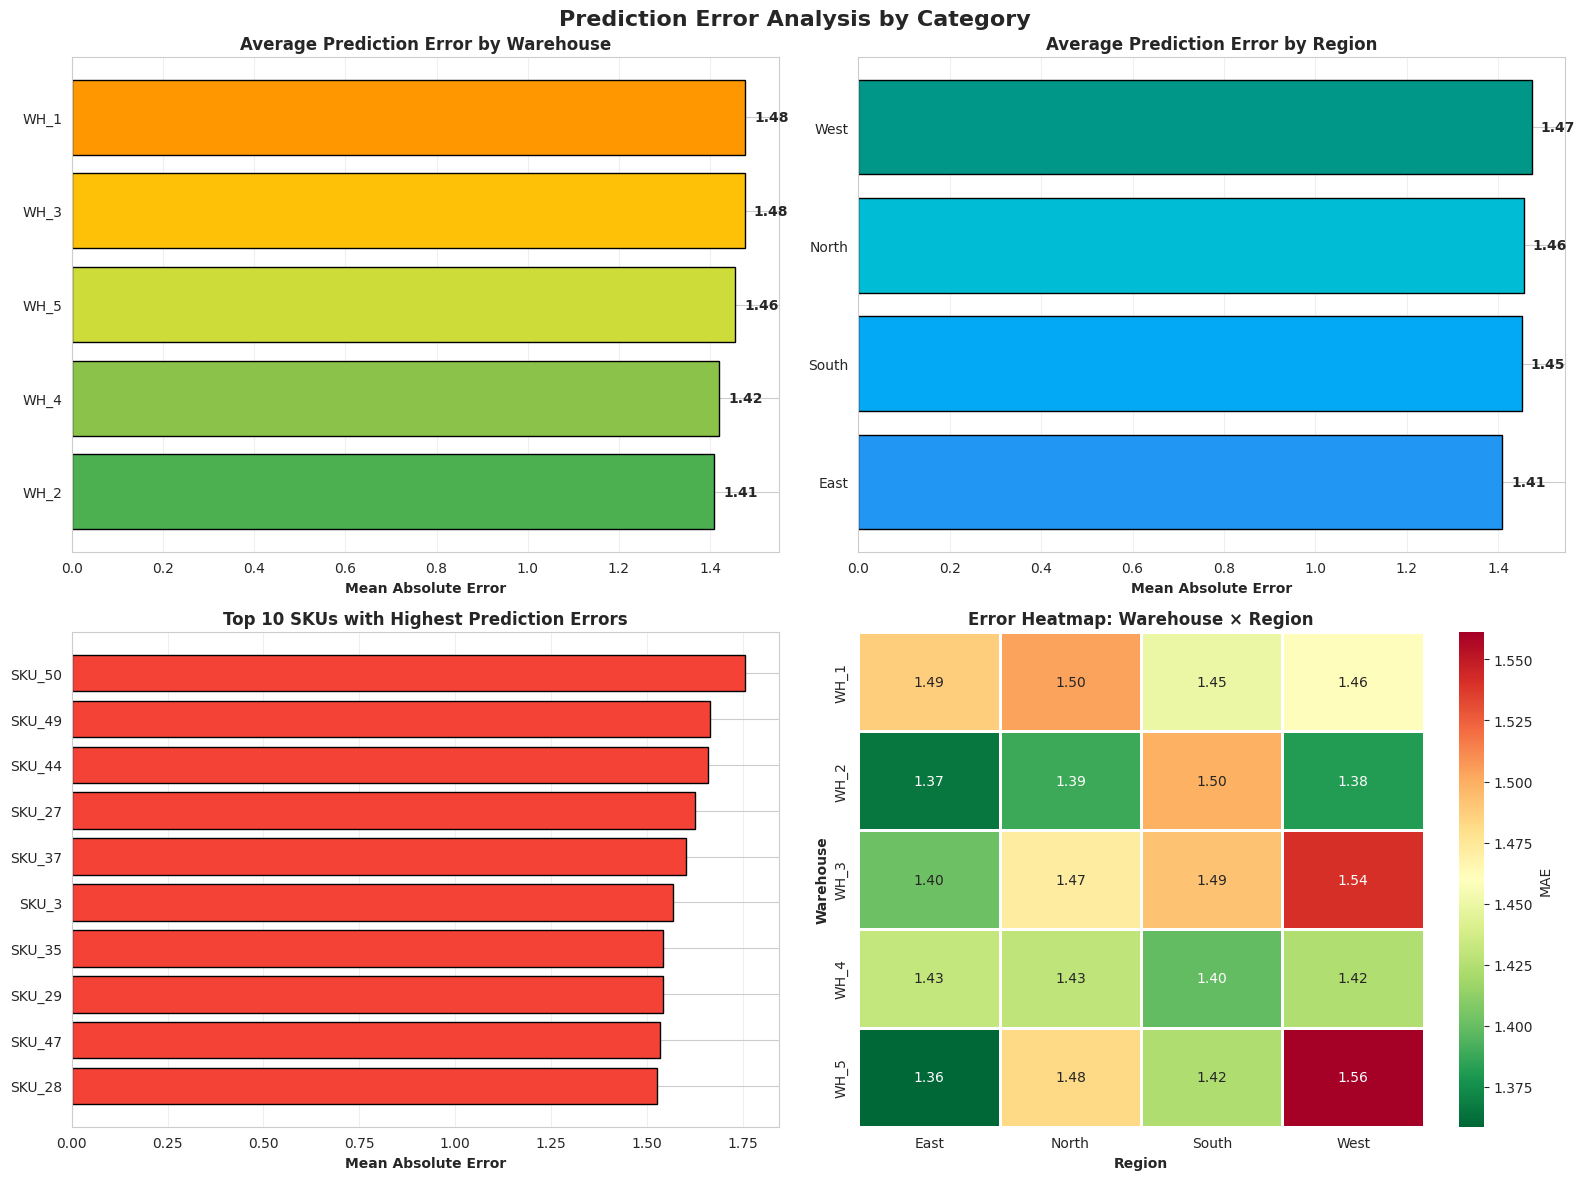

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Error Analysis by Category', fontsize=16, fontweight='bold')

# Error by Warehouse
warehouse_errors = pred_results.groupby('Warehouse').apply(
    lambda x: np.abs(x['Actual'] - x['Predicted']).mean()
).sort_values()

colors_wh = ['#4CAF50', '#8BC34A', '#CDDC39', '#FFC107', '#FF9800']
bars = axes[0,0].barh(warehouse_errors.index, warehouse_errors.values,
                     color=colors_wh, edgecolor='black')
axes[0,0].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[0,0].set_title('Average Prediction Error by Warehouse', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='x')

for i, (idx, val) in enumerate(warehouse_errors.items()):
    axes[0,0].text(val + 0.02, i, f'{val:.2f}', va='center', fontweight='bold')

# Error by Region
region_errors = pred_results.groupby('Region').apply(
    lambda x: np.abs(x['Actual'] - x['Predicted']).mean()
).sort_values()

colors_reg = ['#2196F3', '#03A9F4', '#00BCD4', '#009688']
bars = axes[0,1].barh(region_errors.index, region_errors.values,
                     color=colors_reg, edgecolor='black')
axes[0,1].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[0,1].set_title('Average Prediction Error by Region', fontweight='bold')
axes[0,1].grid(True, alpha=0.3, axis='x')

for i, (idx, val) in enumerate(region_errors.items()):
    axes[0,1].text(val + 0.02, i, f'{val:.2f}', va='center', fontweight='bold')

# Top 10 SKUs with highest errors
sku_errors = pred_results.groupby('SKU').apply(
    lambda x: np.abs(x['Actual'] - x['Predicted']).mean()
).nlargest(10)

axes[1,0].barh(range(len(sku_errors)), sku_errors.values, color='#F44336', edgecolor='black')
axes[1,0].set_yticks(range(len(sku_errors)))
axes[1,0].set_yticklabels(sku_errors.index)
axes[1,0].set_xlabel('Mean Absolute Error', fontweight='bold')
axes[1,0].set_title('Top 10 SKUs with Highest Prediction Errors', fontweight='bold')
axes[1,0].invert_yaxis()
axes[1,0].grid(True, alpha=0.3, axis='x')

# Error distribution heatmap
error_matrix = pred_results.groupby(['Warehouse', 'Region']).apply(
    lambda x: np.abs(x['Actual'] - x['Predicted']).mean()
).unstack()

sns.heatmap(error_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
           ax=axes[1,1], cbar_kws={'label': 'MAE'}, linewidths=1)
axes[1,1].set_title('Error Heatmap: Warehouse × Region', fontweight='bold')
axes[1,1].set_xlabel('Region', fontweight='bold')
axes[1,1].set_ylabel('Warehouse', fontweight='bold')

plt.tight_layout()
plt.show()


# Step 4.6: Model Comparison with Baseline

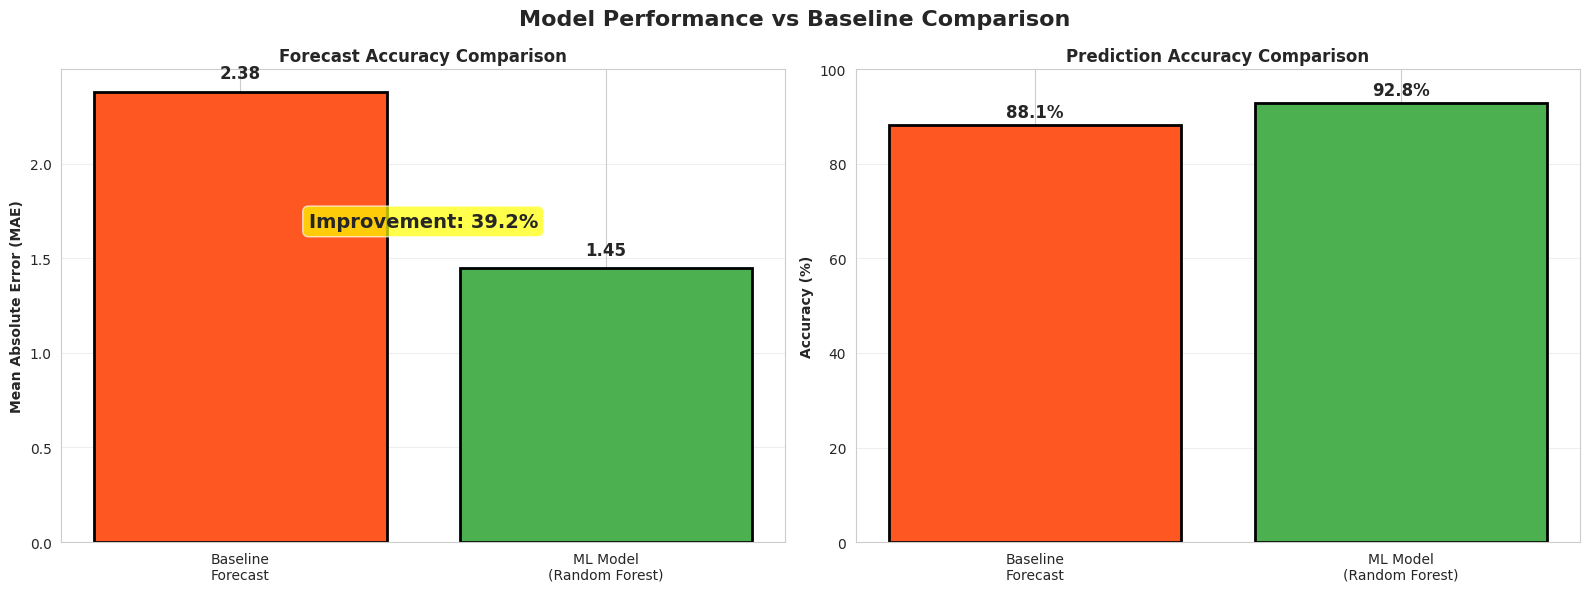

BASELINE vs ML MODEL COMPARISON
Baseline MAE:          2.38 units
ML Model MAE:          1.45 units
Improvement:           39.2%
Baseline Accuracy:     88.13%
ML Model Accuracy:     92.78%


In [32]:
baseline_mae = df_pd['Forecast_Error'].mean()
ml_mae = mae_score
improvement = ((baseline_mae - ml_mae) / baseline_mae) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance vs Baseline Comparison', fontsize=16, fontweight='bold')

# MAE Comparison
methods = ['Baseline\nForecast', 'ML Model\n(Random Forest)']
mae_values = [baseline_mae, ml_mae]
colors = ['#FF5722', '#4CAF50']

bars = axes[0].bar(methods, mae_values, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Mean Absolute Error (MAE)', fontweight='bold')
axes[0].set_title('Forecast Accuracy Comparison', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for i, (method, val) in enumerate(zip(methods, mae_values)):
    axes[0].text(i, val + 0.05, f'{val:.2f}', ha='center',
                va='bottom', fontsize=12, fontweight='bold')

axes[0].text(0.5, max(mae_values) * 0.7,
            f'Improvement: {improvement:.1f}%',
            ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Accuracy Percentage
baseline_acc = (1 - baseline_mae / df_pd['Units_Sold'].mean()) * 100
ml_acc = (1 - ml_mae / df_pd['Units_Sold'].mean()) * 100

accuracy_vals = [baseline_acc, ml_acc]
bars = axes[1].bar(methods, accuracy_vals, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('Prediction Accuracy Comparison', fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

for i, (method, val) in enumerate(zip(methods, accuracy_vals)):
    axes[1].text(i, val + 1, f'{val:.1f}%', ha='center',
                va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("BASELINE vs ML MODEL COMPARISON")
print(f"Baseline MAE:          {baseline_mae:.2f} units")
print(f"ML Model MAE:          {ml_mae:.2f} units")
print(f"Improvement:           {improvement:.1f}%")
print(f"Baseline Accuracy:     {baseline_acc:.2f}%")
print(f"ML Model Accuracy:     {ml_acc:.2f}%")


# Step 4.7: Business Impact Analysis

BUSINESS IMPACT ANALYSIS
Current Forecast Error Cost:    $2,650,051.86
ML Model Forecast Error Cost:   $324,267.46
Potential Cost Savings:         $2,325,784.40
Savings Percentage:             87.76%

Stockout Risk Assessment:
High Risk Items:                421 (2.29%)
Low Risk Items:                 17,937 (97.71%)
Total Items Analyzed:           18,358


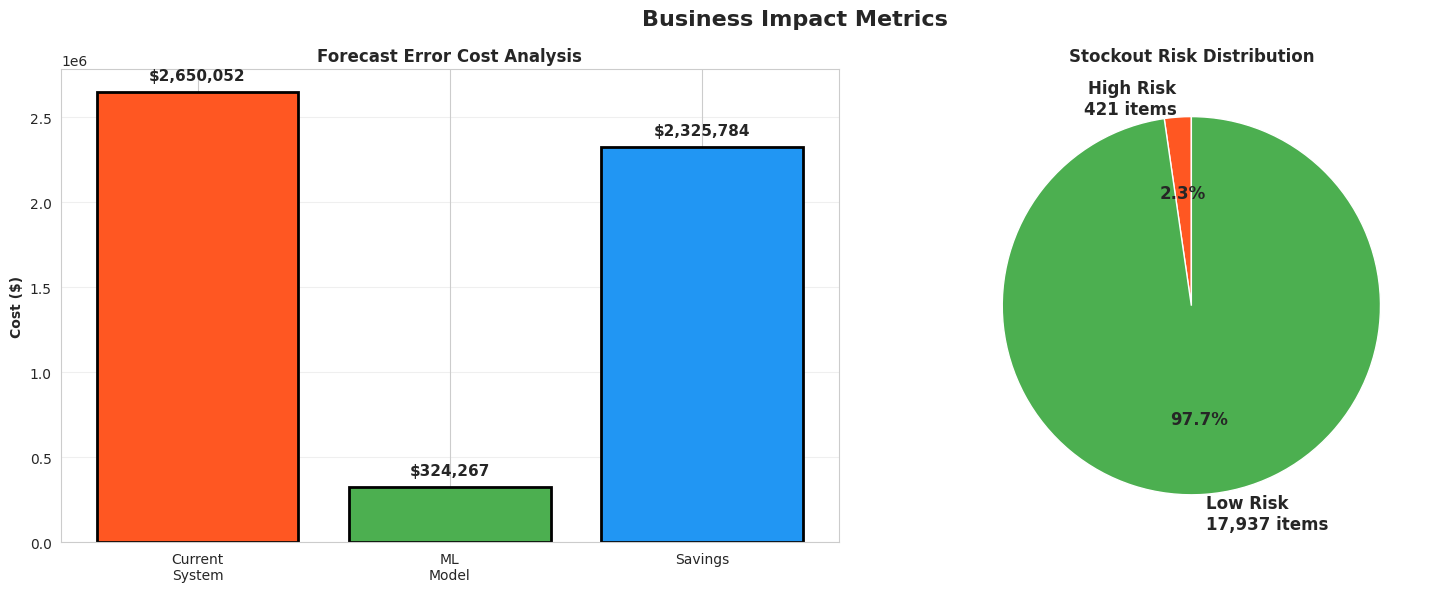

In [33]:
current_forecast_error_cost = df_pd['Forecast_Error'].sum() * df_pd['Unit_Cost'].mean()
ml_forecast_error_cost = mae_score * len(pred_results) * df_pd['Unit_Cost'].mean()
cost_savings = current_forecast_error_cost - ml_forecast_error_cost

print("BUSINESS IMPACT ANALYSIS")
print(f"Current Forecast Error Cost:    ${current_forecast_error_cost:,.2f}")
print(f"ML Model Forecast Error Cost:   ${ml_forecast_error_cost:,.2f}")
print(f"Potential Cost Savings:         ${cost_savings:,.2f}")
print(f"Savings Percentage:             {(cost_savings/current_forecast_error_cost)*100:.2f}%")

high_risk = stockout_predictions.filter(F.col("prediction") == 1).count()
total_items = stockout_predictions.count()
risk_percentage = (high_risk / total_items) * 100

print(f"\nStockout Risk Assessment:")
print(f"High Risk Items:                {high_risk:,} ({risk_percentage:.2f}%)")
print(f"Low Risk Items:                 {total_items - high_risk:,} ({100-risk_percentage:.2f}%)")
print(f"Total Items Analyzed:           {total_items:,}")

# Business metrics visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Business Impact Metrics', fontsize=16, fontweight='bold')

# Cost comparison
cost_categories = ['Current\nSystem', 'ML\nModel', 'Savings']
cost_values = [current_forecast_error_cost, ml_forecast_error_cost, cost_savings]
colors_cost = ['#FF5722', '#4CAF50', '#2196F3']

bars = ax1.bar(cost_categories, cost_values, color=colors_cost, edgecolor='black', linewidth=2)
ax1.set_ylabel('Cost ($)', fontweight='bold')
ax1.set_title('Forecast Error Cost Analysis', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for i, val in enumerate(cost_values):
    ax1.text(i, val + max(cost_values)*0.02, f'${val:,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Risk distribution
risk_data = [high_risk, total_items - high_risk]
risk_labels = [f'High Risk\n{high_risk:,} items', f'Low Risk\n{total_items - high_risk:,} items']
colors_risk = ['#FF5722', '#4CAF50']

wedges, texts, autotexts = ax2.pie(risk_data, labels=risk_labels, autopct='%1.1f%%',
                                    colors=colors_risk, startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Stockout Risk Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


#Step 4.8: Save Results

In [34]:
output_dir = "/content/drive/MyDrive/Open_ended_experiment_Big_Data_lab/"

pred_results.to_csv(f"{output_dir}demand_predictions.csv", index=False)
print(f" Saved: demand_predictions.csv")

stockout_results = stockout_predictions.select(
    "Stockout_Risk", "prediction", "probability",
    "SKU_ID", "Warehouse_ID", "Inventory_Level", "Reorder_Point"
).toPandas()
stockout_results.to_csv(f"{output_dir}stockout_predictions.csv", index=False)
print(f" Saved: stockout_predictions.csv")

importance_df.to_csv(f"{output_dir}feature_importance.csv", index=False)
print(f" Saved: feature_importance.csv")

performance_summary = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE', 'Classification Accuracy', 'F1 Score',
               'Baseline MAE', 'Improvement %', 'Cost Savings'],
    'Value': [r2_score, rmse_score, mae_score, accuracy_score, f1_score,
             baseline_mae, improvement, cost_savings]
})
performance_summary.to_csv(f"{output_dir}model_performance.csv", index=False)
print(f" Saved: model_performance.csv")

demand_model.write().overwrite().save(f"{output_dir}demand_forecast_model")
print(f" Saved: demand_forecast_model")

stockout_model.write().overwrite().save(f"{output_dir}stockout_risk_model")
print(f" Saved: stockout_risk_model")

print("ALL TASKS COMPLETED SUCCESSFULLY!")
print(f"Generated {len(pred_results):,} predictions")
print(f"Trained 2 ML models with {len(all_model_features)} features")
print(f"Achieved {improvement:.1f}% improvement over baseline")
print(f"Potential savings: ${cost_savings:,.2f}")
print("All results and models saved to Google Drive")

spark.stop()
print("\n Spark session closed successfully")


 Saved: demand_predictions.csv
 Saved: stockout_predictions.csv
 Saved: feature_importance.csv
 Saved: model_performance.csv
 Saved: demand_forecast_model
 Saved: stockout_risk_model
ALL TASKS COMPLETED SUCCESSFULLY!
Generated 18,358 predictions
Trained 2 ML models with 13 features
Achieved 39.2% improvement over baseline
Potential savings: $2,325,784.40
All results and models saved to Google Drive

 Spark session closed successfully
